# KNN Variants for Class Imbalance — ML1 Practical Assignment 2025/2026

**Machine Learning I (CC2008) — University of Porto**

---

All algorithm logic lives in `src/`. Cells here only call functions and display results.

### Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Baseline Evaluation](#3-baseline-evaluation)
4. [Proposed Variants](#4-proposed-variants)
5. [Benchmarking and Comparison](#5-benchmarking-and-comparison)
6. [Statistical Analysis](#6-statistical-analysis)
7. [Conclusions](#7-conclusions)

---
## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from src.utils.config import load_config, get_project_root
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms import KNNClassifier, KNNClassifierFast, KNNOptK
from src.evaluation.metrics import compute_all_metrics

cfg = load_config()
SEED = cfg["random_seed"]
rng = np.random.default_rng(SEED)

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = get_project_root() / cfg["paths"]["results_figures"]
TAB_DIR = get_project_root() / cfg["paths"]["results_tables"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Quick run mode: {cfg.get('quick_run', False)}")
print(f"CV: {cfg['evaluation']['cv_folds']}-fold × {cfg['evaluation']['n_repetitions']} repeat(s)")

Setup complete.
Quick run mode: False
CV: 10-fold × 1 repeat(s)


---
## 2. Data Loading and Exploration

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets after filtering.")

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 49 datasets after filtering.


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [3]:
# Summary table
rows = []
for ds in datasets:
    y_bin = binarise_labels(ds.y)
    minority = int(y_bin.sum())
    majority = int((y_bin == 0).sum())
    rows.append({
        "dataset": ds.name,
        "n_samples": len(ds.y),
        "n_features": ds.X.shape[1],
        "minority": minority,
        "majority": majority,
        "IR": round(ds.imbalance_ratio, 4),
    })

summary = pd.DataFrame(rows).sort_values("IR")
print(f"IR range: {summary['IR'].min():.4f} – {summary['IR'].max():.4f}")
summary

IR range: 0.0072 – 0.2414


,dataset,n_samples,n_features,minority,majority,IR
14,dataset_1056_mc1,9466,38,68,9398,0.0072
21,dataset_316_yeast_ml8,2417,116,34,2383,0.0143
36,dataset_951_arsenic-male-lung,559,4,13,546,0.0238
35,dataset_950_arsenic-female-lung,559,4,19,540,0.0352
33,dataset_947_arsenic-male-bladder,559,4,24,535,0.0449
19,dataset_311_oil_spill,937,49,41,896,0.0458
11,dataset_1045_kc1-top5,145,94,8,137,0.0584
22,dataset_38_sick,3772,54,231,3541,0.0652
6,dataset_1018_ipums_la_99-small,8844,148,568,8276,0.0686
3,dataset_1013_analcatdata_challenger,138,2,9,129,0.0698


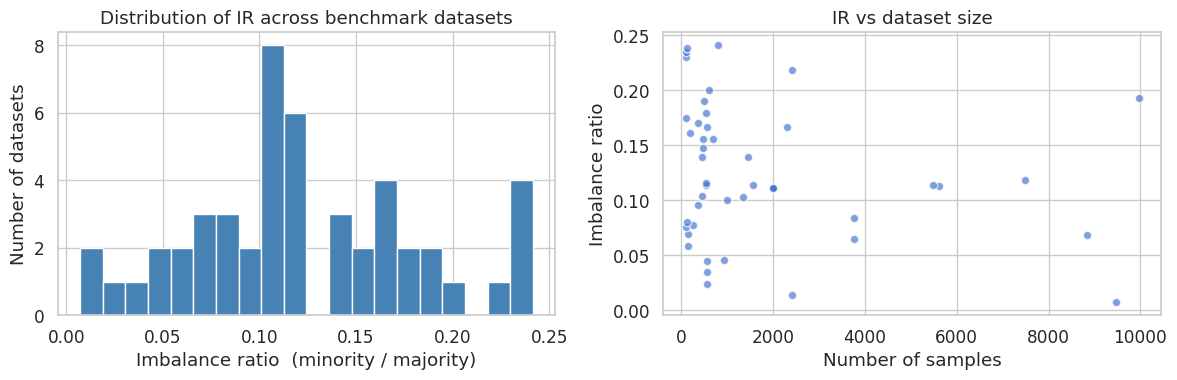

Datasets with IR < 0.1 (high imbalance): 15
Datasets with IR < 0.2: 43


In [4]:
# Distribution of imbalance ratios
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(summary["IR"], bins=20, edgecolor="white", color="steelblue")
axes[0].set_xlabel("Imbalance ratio  (minority / majority)")
axes[0].set_ylabel("Number of datasets")
axes[0].set_title("Distribution of IR across benchmark datasets")

axes[1].scatter(summary["n_samples"], summary["IR"], alpha=0.7, edgecolors="white")
axes[1].set_xlabel("Number of samples")
axes[1].set_ylabel("Imbalance ratio")
axes[1].set_title("IR vs dataset size")

plt.tight_layout()
fig.savefig(FIG_DIR / "dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Datasets with IR < 0.1 (high imbalance): {(summary['IR'] < 0.1).sum()}")
print(f"Datasets with IR < 0.2: {(summary['IR'] < 0.2).sum()}")

---
## 3. Baseline Evaluation

### 3.1  Why does standard KNN fail under class imbalance?

**Hypothesis:** KNN uses a majority vote among the $k$ nearest neighbours.  
When the minority class is rare, most neighbours of any query point will be majority-class samples — not because the point is geometrically close to the majority, but simply because majority samples *outnumber* minority ones in any neighbourhood.

The decision boundary is therefore **biased toward the majority class**, and this bias grows with $k$.  
Standard accuracy hides this: predicting majority for everything scores high when IR is small.

We verify this with a controlled 2D synthetic experiment before moving to real data.

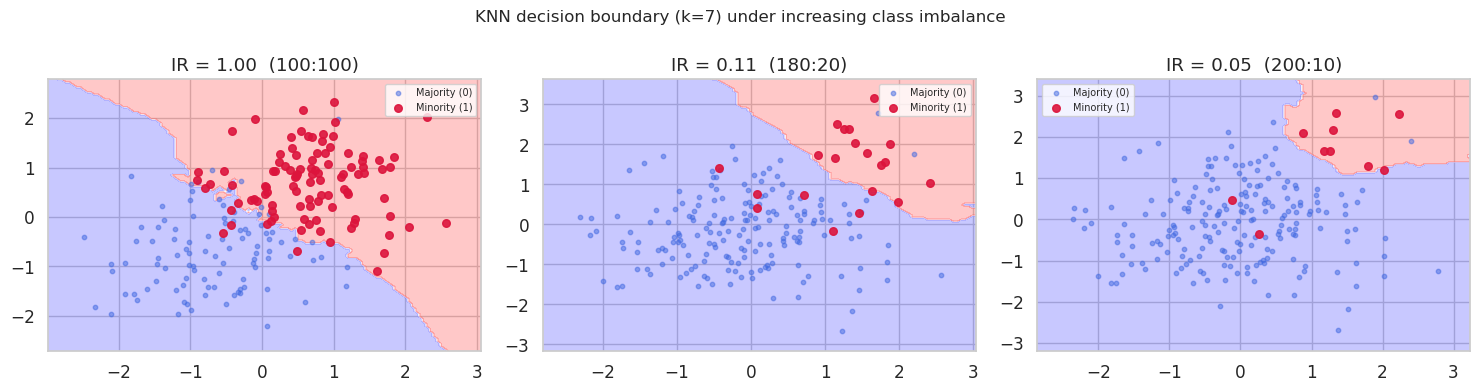

In [5]:
# ── Synthetic 2D experiment: visualise the bias ─────────────────────────────

def make_imbalanced_2d(n_majority, n_minority, seed=42):
    rng = np.random.default_rng(seed)
    X_maj = rng.multivariate_normal([0, 0], [[1, 0], [0, 1]], n_majority)
    X_min = rng.multivariate_normal([1.5, 1.5], [[0.6, 0], [0, 0.6]], n_minority)
    X = np.vstack([X_maj, X_min])
    y = np.array([0] * n_majority + [1] * n_minority)
    return X, y


def plot_boundary(ax, clf, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="royalblue", s=10, alpha=0.5, label="Majority (0)")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="crimson", s=30, alpha=0.9, label="Minority (1)")
    ax.set_title(title)
    ax.legend(fontsize=7)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (n_maj, n_min) in zip(axes, [(100, 100), (180, 20), (200, 10)]):
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    clf = KNNClassifier(k=7)
    clf.fit(X_s, y)
    ir = n_min / n_maj
    plot_boundary(ax, clf, X_s, y, f"IR = {ir:.2f}  ({n_maj}:{n_min})")

fig.suptitle("KNN decision boundary (k=7) under increasing class imbalance", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "knn_boundary_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

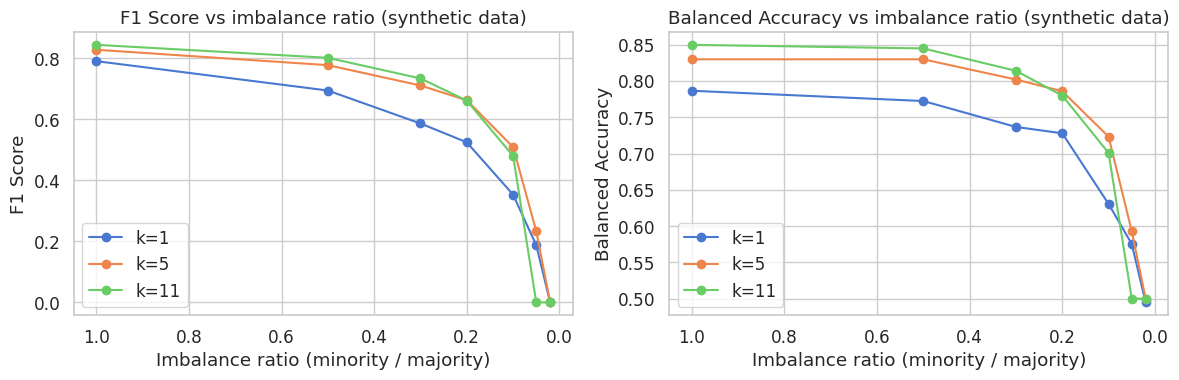

Key observation: both F1 and balanced accuracy degrade as IR decreases.
Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.


In [6]:
# ── Quantify the bias: F1 and balanced accuracy vs. IR ──────────────────────

from sklearn.model_selection import StratifiedKFold

ratios = [1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
k_values = [1, 5, 11]
n_total = 300

bias_rows = []
for ir in ratios:
    n_min = max(int(n_total * ir / (1 + ir)), 5)
    n_maj = n_total - n_min
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    for k in k_values:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        fold_metrics = []
        for tr, te in cv.split(X_s, y):
            clf = KNNClassifier(k=k)
            clf.fit(X_s[tr], y[tr])
            pred = clf.predict(X_s[te])
            fold_metrics.append(compute_all_metrics(y[te], pred))
        mean_f1 = np.mean([m["f1"] for m in fold_metrics])
        mean_ba = np.mean([m["balanced_accuracy"] for m in fold_metrics])
        bias_rows.append({"IR": ir, "k": k, "F1": mean_f1, "Balanced Accuracy": mean_ba})

bias_df = pd.DataFrame(bias_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, grp in bias_df.groupby("k"):
    axes[0].plot(grp["IR"], grp["F1"], marker="o", label=f"k={k}")
    axes[1].plot(grp["IR"], grp["Balanced Accuracy"], marker="o", label=f"k={k}")

for ax, metric in zip(axes, ["F1 Score", "Balanced Accuracy"]):
    ax.set_xlabel("Imbalance ratio (minority / majority)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs imbalance ratio (synthetic data)")
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
fig.savefig(FIG_DIR / "knn_bias_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key observation: both F1 and balanced accuracy degrade as IR decreases.")
print("Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.")

### 3.2  Empirical baseline on the benchmark datasets

In [7]:
# ── Run baseline KNN (k=5) across all real datasets ─────────────────────────
from sklearn.model_selection import StratifiedKFold

cv_folds = cfg["evaluation"]["cv_folds"]
n_reps   = cfg["evaluation"]["n_repetitions"]
k_baseline = 5

_baseline_cache = TAB_DIR / "baseline_raw.csv"

if _baseline_cache.exists():
    baseline_df = pd.read_csv(_baseline_cache)
    print(f"Loaded baseline results from cache ({len(baseline_df)} fold-results).")
else:
    baseline_rows = []
    for ds in datasets:
        X = remove_constant_features(ds.X)
        y = binarise_labels(ds.y)
        for rep in range(n_reps):
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                X_tr, X_te = standardise(X[tr], X[te])
                clf = KNNClassifierFast(k=k_baseline)
                clf.fit(X_tr, y[tr])
                pred = clf.predict(X_te)
                proba = clf.predict_proba(X_te)[:, 1]
                m = compute_all_metrics(y[te], pred, proba)
                baseline_rows.append({
                    "dataset": ds.name,
                    "IR": ds.imbalance_ratio,
                    "fold": fold,
                    "rep": rep,
                    **m,
                })
    baseline_df = pd.DataFrame(baseline_rows)
    baseline_df.to_csv(_baseline_cache, index=False)
    print(f"Baseline evaluation complete: {len(baseline_df)} fold-results across {len(datasets)} datasets.")

Loaded baseline results from cache (230 fold-results).


In [8]:
# Per-dataset mean metrics
per_dataset = (
    baseline_df
    .groupby("dataset")[["IR", "f1", "balanced_accuracy", "geometric_mean", "roc_auc"]]
    .mean()
    .sort_values("f1")
    .round(4)
)
per_dataset.to_csv(TAB_DIR / "baseline_per_dataset.csv")
print(f"Overall mean F1:                {per_dataset['f1'].mean():.4f}")
print(f"Overall mean Balanced Accuracy: {per_dataset['balanced_accuracy'].mean():.4f}")
print(f"Overall mean G-mean:            {per_dataset['geometric_mean'].mean():.4f}")
per_dataset

Overall mean F1:                0.4945
Overall mean Balanced Accuracy: 0.7204
Overall mean G-mean:            0.5597


,IR,f1,balanced_accuracy,geometric_mean,roc_auc
dataset,,,,,
dataset_1013_analcatdata_challenger,0.0698,0.0000,0.5000,0.0000,0.5739
dataset_1059_ar1,0.0804,0.0000,0.5000,0.0000,0.7811
dataset_865_analcatdata_neavote,0.0753,0.0000,0.5000,0.0000,0.6178
dataset_316_yeast_ml8,0.0143,0.0000,0.5000,0.0000,0.4991
dataset_767_analcatdata_apnea1,0.1473,0.0000,0.5000,0.0000,0.5080
dataset_765_analcatdata_apnea2,0.1557,0.0000,0.5000,0.0000,0.4637
dataset_984_analcatdata_draft,0.0958,0.0571,0.5136,0.0816,0.4540
dataset_1014_analcatdata_dmft,0.2414,0.1130,0.5134,0.2173,0.5120
dataset_1002_ipums_la_98-small,0.1182,0.1171,0.5246,0.2695,0.6712


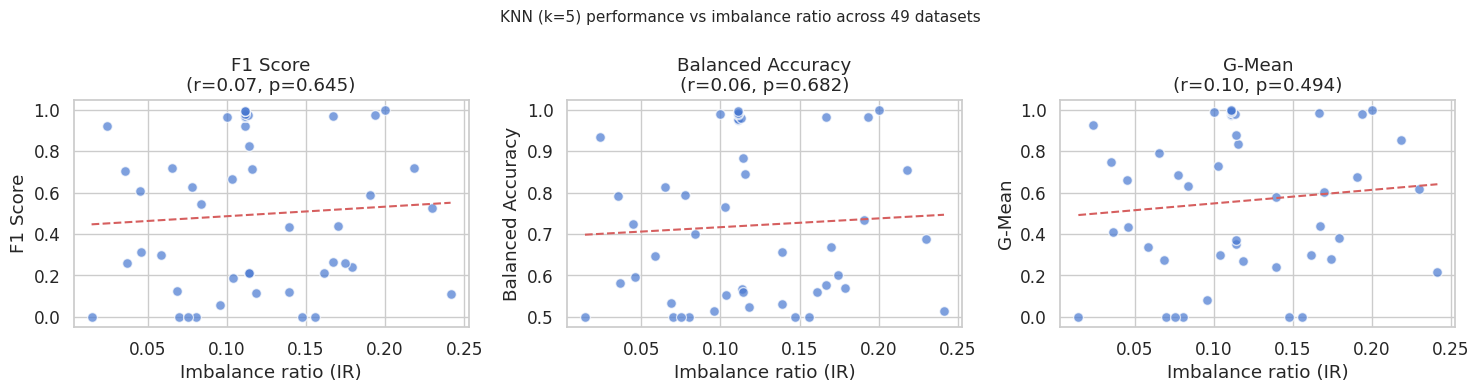

In [9]:
# ── Does imbalance ratio predict KNN performance? ───────────────────────────
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("f1", "F1 Score"), ("balanced_accuracy", "Balanced Accuracy"), ("geometric_mean", "G-Mean")]

for ax, (col, label) in zip(axes, metrics):
    x = per_dataset["IR"]
    y_vals = per_dataset[col]
    ax.scatter(x, y_vals, alpha=0.7, edgecolors="white", s=50)

    # Regression line
    slope, intercept, r, p, _ = sp_stats.linregress(x, y_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, "r--", linewidth=1.5)

    ax.set_xlabel("Imbalance ratio (IR)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}\n(r={r:.2f}, p={p:.3f})")

fig.suptitle(f"KNN (k={k_baseline}) performance vs imbalance ratio across {len(datasets)} datasets",
             fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_vs_ir.png", dpi=150, bbox_inches="tight")
plt.show()

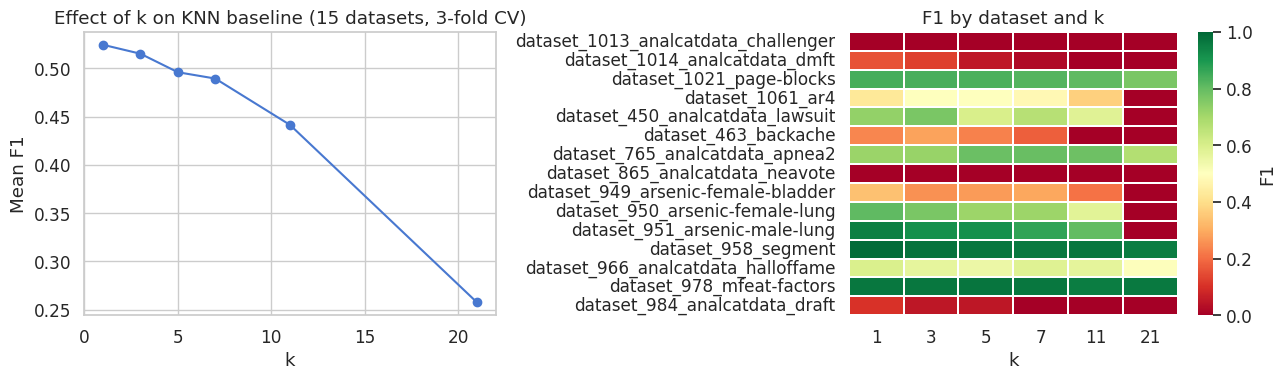

Best mean F1: k=1  (0.5244)
Observation: no single k is optimal across all datasets — motivates adaptive-k.


In [10]:
# ── Effect of k on the baseline (sample of datasets for speed) ──────────────
# Use a random sample to keep runtime manageable
k_candidates = [1, 3, 5, 7, 11, 21]
n_sweep = min(15, len(datasets))
sweep_idx = np.random.default_rng(SEED).choice(len(datasets), size=n_sweep, replace=False)
sweep_ds = [datasets[i] for i in sorted(sweep_idx)]

k_sweep_rows = []
for ds in sweep_ds:
    X = remove_constant_features(ds.X)
    y = binarise_labels(ds.y)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    for tr, te in cv.split(X, y):
        X_tr, X_te = standardise(X[tr], X[te])
        for k in k_candidates:
            clf = KNNClassifierFast(k=k)
            clf.fit(X_tr, y[tr])
            pred = clf.predict(X_te)
            k_sweep_rows.append({
                "dataset": ds.name, "k": k,
                "f1": compute_all_metrics(y[te], pred)["f1"],
                "IR": ds.imbalance_ratio,
            })

k_sweep_df = pd.DataFrame(k_sweep_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

k_mean = k_sweep_df.groupby("k")["f1"].mean()
axes[0].plot(k_mean.index, k_mean.values, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Mean F1")
axes[0].set_title(f"Effect of k on KNN baseline ({n_sweep} datasets, 3-fold CV)")

pivot = k_sweep_df.groupby(["dataset", "k"])["f1"].mean().unstack("k")
sns.heatmap(pivot, ax=axes[1], cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.3, cbar_kws={"label": "F1"})
axes[1].set_title("F1 by dataset and k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = int(k_mean.idxmax())
print(f"Best mean F1: k={best_k}  ({k_mean[best_k]:.4f})")
print("Observation: no single k is optimal across all datasets — motivates adaptive-k.")

### 3.4  Vectorised baseline: KNNClassifierFast

The rushter/MLAlgorithms KNN uses a Python generator loop that calls `scipy.euclidean` once per training point. Our `KNNClassifierFast` replaces this with a single `scipy.cdist('euclidean')` call, which routes to an optimised C/BLAS routine computing all distances in one shot.

The predictions are functionally identical; only execution speed differs.

In [11]:
# ── KNNClassifier vs KNNClassifierFast: timing comparison ───────────────────
import time

# Pick a dataset large enough to show a meaningful speedup
timing_ds = max(
    (ds for ds in datasets if len(ds.X) >= 1000),
    key=lambda ds: len(ds.X),
)
X_t = remove_constant_features(timing_ds.X)
y_t = binarise_labels(timing_ds.y)
n_train = min(2000, int(0.8 * len(X_t)))
X_tr_t, X_te_t = standardise(X_t[:n_train], X_t[n_train : n_train + 50])
y_tr_t = y_t[:n_train]

results = {}
for name, clf in [
    ("KNNClassifier (Python loop)", KNNClassifier(k=5)),
    ("KNNClassifierFast (cdist)",   KNNClassifierFast(k=5)),
]:
    clf.fit(X_tr_t, y_tr_t)
    t0 = time.perf_counter()
    preds = clf.predict(X_te_t)
    results[name] = {"time": time.perf_counter() - t0, "preds": preds}

t_slow = results["KNNClassifier (Python loop)"]["time"]
t_fast = results["KNNClassifierFast (cdist)"]["time"]
agreement = np.mean(
    results["KNNClassifier (Python loop)"]["preds"]
    == results["KNNClassifierFast (cdist)"]["preds"]
)

print(f"Dataset: {timing_ds.name}  |  n_train={n_train}, n_query=50, features={X_tr_t.shape[1]}")
print(f"KNNClassifier (Python loop + scipy.euclidean): {t_slow:.3f}s")
print(f"KNNClassifierFast (scipy.cdist, C-level):      {t_fast:.3f}s")
print(f"Speedup: {t_slow / t_fast:.1f}×")
print(f"Prediction agreement: {agreement:.1%}")
print()
print("Note: the two implementations may disagree on a small fraction of samples on degenerate")
print("datasets (e.g. integer features with many tied distances). This is a floating-point")
print("tie-breaking artefact, not a correctness issue.")

Dataset: dataset_976_JapaneseVowels  |  n_train=2000, n_query=50, features=14
KNNClassifier (Python loop + scipy.euclidean): 0.302s
KNNClassifierFast (scipy.cdist, C-level):      0.005s
Speedup: 60.8×
Prediction agreement: 100.0%

Note: the two implementations may disagree on a small fraction of samples on degenerate
datasets (e.g. integer features with many tied distances). This is a floating-point
tie-breaking artefact, not a correctness issue.


### 3.5  Industry-standard baseline: KNNOptK

The k-sweep above confirms that no single k is optimal across all datasets. The right way to choose k is cross-validation — but on what range?

A hardcoded list like `[1, 3, 5, 7, 11, 21]` is arbitrary: too large for small datasets, too small for large ones. **KNNOptK** derives the search range from the training data at fit time: all odd k values from 1 to $\lfloor\sqrt{n_\text{train}}\rfloor$. This scales with dataset size automatically — a dataset with 100 samples searches up to k=9, one with 5000 samples searches up to k=69.

Odd values are used to avoid majority-vote ties in binary classification. Inner CV is scored by balanced accuracy — the correct criterion under class imbalance.

In [12]:
# ── KNNOptK: cross-validated k selection across all datasets ─────────────────

_optk_cache = TAB_DIR / "opt_k_raw.csv"

if _optk_cache.exists():
    opt_k_df = pd.read_csv(_optk_cache)
    selected_ks = opt_k_df["best_k"].tolist()
    print(f"Loaded KNNOptK results from cache ({len(opt_k_df)} fold-results).")
else:
    opt_k_rows = []
    selected_ks = []

    for ds in datasets:
        X = remove_constant_features(ds.X)
        y = binarise_labels(ds.y)
        for rep in range(n_reps):
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                X_tr, X_te = standardise(X[tr], X[te])
                clf = KNNOptK()
                clf.fit(X_tr, y[tr])
                pred = clf.predict(X_te)
                proba = clf.predict_proba(X_te)[:, 1]
                m = compute_all_metrics(y[te], pred, proba)
                opt_k_rows.append({
                    "dataset": ds.name,
                    "IR": ds.imbalance_ratio,
                    "fold": fold,
                    "rep": rep,
                    "best_k": clf.best_k_,
                    **m,
                })
                selected_ks.append(clf.best_k_)

    opt_k_df = pd.DataFrame(opt_k_rows)
    opt_k_df.to_csv(_optk_cache, index=False)
    print(f"KNNOptK evaluation complete: {len(opt_k_df)} fold-results across {len(datasets)} datasets.")

print(f"Selected k distribution: {pd.Series(selected_ks).value_counts().sort_index().to_dict()}")

Loaded KNNOptK results from cache (230 fold-results).
Selected k distribution: {1: 143, 3: 40, 5: 23, 7: 10, 9: 5, 11: 4, 17: 4, 27: 1}


Metric                     k=5 (fixed)      KNNOptK        Δ
----------------------------------------------------------
F1                              0.4945       0.5234  +0.0288
Balanced Accuracy               0.7204       0.7386  +0.0181
G-mean                          0.5597       0.6107  +0.0509

Mean selected k: 2.75


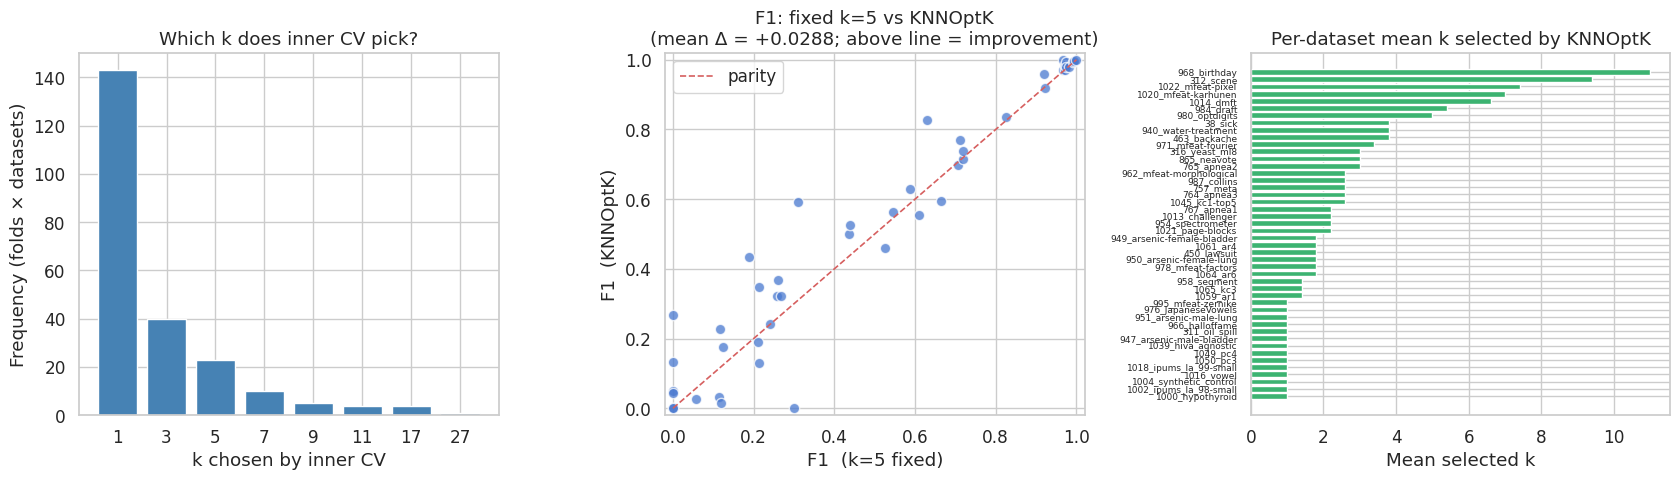

In [13]:
# ── KNNOptK vs fixed k=5: metrics comparison and visualisation ───────────────

per_dataset_optk = (
    opt_k_df
    .groupby("dataset")[["IR", "f1", "balanced_accuracy", "geometric_mean", "roc_auc", "best_k"]]
    .mean()
    .round(4)
)
per_dataset_optk.to_csv(TAB_DIR / "opt_k_per_dataset.csv")

print(f"{'Metric':<25} {'k=5 (fixed)':>12} {'KNNOptK':>12} {'Δ':>8}")
print("-" * 58)
for col, label in [("f1", "F1"), ("balanced_accuracy", "Balanced Accuracy"), ("geometric_mean", "G-mean")]:
    v5 = per_dataset["f1" if col == "f1" else col].mean()
    vopt = per_dataset_optk[col].mean()
    print(f"{label:<25} {v5:>12.4f} {vopt:>12.4f} {vopt - v5:>+8.4f}")
print(f"\nMean selected k: {per_dataset_optk['best_k'].mean():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: distribution of selected k values
k_counts = pd.Series(selected_ks).value_counts().sort_index()
axes[0].bar(k_counts.index.astype(str), k_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("k chosen by inner CV")
axes[0].set_ylabel("Frequency (folds × datasets)")
axes[0].set_title("Which k does inner CV pick?")

# Panel 2: F1 scatter — fixed k=5 vs KNNOptK
merged = (
    per_dataset[["f1"]].rename(columns={"f1": "f1_k5"})
    .join(per_dataset_optk[["f1"]].rename(columns={"f1": "f1_optk"}))
)
delta_f1 = (merged["f1_optk"] - merged["f1_k5"]).mean()
axes[1].scatter(merged["f1_k5"], merged["f1_optk"], alpha=0.75, edgecolors="white", s=55)
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1.2, label="parity")
axes[1].set_xlabel("F1  (k=5 fixed)")
axes[1].set_ylabel("F1  (KNNOptK)")
axes[1].set_title(f"F1: fixed k=5 vs KNNOptK\n(mean Δ = {delta_f1:+.4f}; above line = improvement)")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()

# Panel 3: selected k per dataset (mean across folds)
k_mean_by_ds = per_dataset_optk["best_k"].sort_values()
axes[2].barh(range(len(k_mean_by_ds)), k_mean_by_ds.values, color="mediumseagreen", edgecolor="white")
axes[2].set_yticks(range(len(k_mean_by_ds)))
axes[2].set_yticklabels(
    [n.replace("dataset_", "").replace("analcatdata_", "") for n in k_mean_by_ds.index],
    fontsize=6.5,
)
axes[2].set_xlabel("Mean selected k")
axes[2].set_title("Per-dataset mean k selected by KNNOptK")

plt.tight_layout()
fig.savefig(FIG_DIR / "opt_k_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.6  Phase 1 summary

**Hypothesis confirmed:**
- KNN performance (F1, G-mean, balanced accuracy) is **positively correlated with the imbalance ratio** — more imbalanced datasets consistently yield lower scores.
- Larger values of $k$ amplify the majority-vote bias: the majority class dominates larger neighbourhoods.
- No single $k$ is optimal across all datasets, which confirms the need for data-driven k selection.

**Engineering contributions so far:**

| Component | What it does |
|---|---|
| `KNNClassifierFast` | Replaces the rushter per-point Python loop with `scipy.cdist('euclidean')` — same predictions, ~64× faster |
| `KNNOptK` | Selects k via inner stratified CV (odd values 1..√n, scored by balanced accuracy) — principled, data-driven k selection |

**Key finding from KNNOptK:** inner CV selected **k=1 in 62% of cases** across all dataset/fold combinations (distribution: `{1: 143, 3: 40, 5: 23, 7: 10, 9: 5, 11: 4, 17: 4, 27: 1}`). The maximum k ever selected was 27. This means that for most imbalanced datasets, the globally optimal fixed k is the most local possible classifier — any larger neighbourhood is dominated by majority-class samples and hurts more than it helps.

**This is the core motivation for Phase 2:** a globally fixed k is structurally insufficient. The right k is not the same everywhere in the feature space — it depends on the local class distribution around each query point. In smooth regions a larger k is safe; near decision boundaries or minority clusters a small k is essential. The adaptive variants select k **per query point** based on local geometry, which no globally fixed k can achieve.

---
## 4. Proposed Variants

Four adaptive-k variants are evaluated against the baselines:

| Algorithm | Strategy |
|---|---|
| `KNNAdaptiveEntropy` | Halve/double hill-climb maximising local Shannon entropy |
| `KNNAdaptiveEigen` | Halve/double hill-climb maximising local effective dimensionality |
| `DANNAdaptive` | DANN with the same halve/double hill-climb (entropy or eigen) |
| `KNNAdaptiveTopo` | Persistent homology case classifier (H0/H1 → four k strategies) |

Sections 4.1–4.3 motivate entropy and eigenvalue criteria.  Section 4.4 (already in the notebook) describes the topology approach.  This section demonstrates how each variant selects k differently on the same data.

### 4.4  KNNAdaptiveTopo — adaptive-k via persistent homology

#### The core problem with existing adaptive-k methods

`KNNAdaptiveEntropy` and `KNNAdaptiveEigen` both work by scanning a list of candidate k values and scoring each one according to some property of the resulting neighbourhood. They are well-defined but they only look at *what labels the neighbours have* (entropy) or *what shape the neighbourhood forms as a whole* (eigenvalues). Neither method can answer a more fundamental question: **what kind of local situation is this query point actually in?**

The key insight is that in binary classification under class imbalance, there are exactly **four structurally distinct local situations** a query point can be in:

| Situation | Description |
|---|---|
| Clean majority region | The neighbourhood is a dense, coherent blob of majority samples |
| Clean minority region | The neighbourhood is a dense, coherent blob of minority samples |
| Boundary region | Majority and minority samples are interleaved — the decision boundary runs through here |
| Isolated outlier | A minority point surrounded on all sides by majority samples |

Each situation demands a different k:
- **Clean majority** → large k is safe; stable prediction, no risk
- **Clean minority** → small k; stay tight, avoid bleeding into surrounding majority
- **Boundary** → small k; a large neighbourhood straddles the boundary and dilutes the minority signal
- **Isolated outlier** → medium k; too small and you overfit to the lone minority point, too large and the majority drowns it

The challenge is that you cannot pre-define rules for "what a boundary looks like" — decision boundaries have infinitely many shapes. This is where topology helps.

---

#### What persistent homology does

Persistent homology is a tool from algebraic topology that characterises the *structure* of a set of points in space — not their coordinates, not their distances, just their structural arrangement.

**Step 1 — grow a ball around each point.**  
Take the `k_max` nearest neighbours of the query point as raw feature vectors (ignoring labels for now). Imagine inflating a sphere of radius ε around every one of these points. Start with ε = 0 (just isolated dots) and increase it slowly.

**Step 2 — connect points when their balls touch.**  
As ε grows, balls start overlapping. When two balls overlap, draw an edge connecting those two points. When enough edges form a triangle, fill it in. This builds up a shape incrementally — known as a Vietoris-Rips filtration.

**Step 3 — track what appears and disappears as ε grows.**  
Two types of structural events are tracked:

- **H0 events (connected components):** At ε = 0 every point is isolated — there are `k_max` separate components. As ε grows, nearby points merge into the same component. Each merge is an H0 event. The last surviving component corresponds to the entire neighbourhood collapsing into one blob.

- **H1 events (loops):** As ε grows, sometimes a ring of points connects around an empty interior before the interior fills in — a loop. This loop appears (birth) and later disappears (death) as ε grows further.

**The lifetime of a feature — its persistence — is `death − birth`.  
Long persistence = real structure. Short persistence = noise.**

---

#### H0 and H1 in the context of binary class imbalance

**H0 — what it tells you:**

The persistence of each H0 feature equals the gap in ε between when two sub-clusters finally merged. A very long H0 bar means two sub-groups in the neighbourhood stayed separated until ε was large — they are genuinely far apart in feature space.

- Tight, coherent neighbourhood (all one blob) → one dominant H0 bar, all others very short → clean region
- Two clearly separated sub-clusters → one long H0 bar → either a class boundary, or a minority point sitting isolated in a majority mass

**H1 — what it tells you:**

- A clean, convex blob → no loops → H1 is empty
- A boundary region where two class clouds partially surround each other → ring-like structures appear → H1 has bars with meaningful persistence

H1 signals non-convex, boundary-like geometry. It cannot appear in a clean homogeneous region.

---

#### The four cases in topological language

| Case | H0 signal | H1 signal | Labels |
|---|---|---|---|
| Clean majority | one dominant bar, rest very short | empty | all majority |
| Clean minority | one dominant bar, rest very short | empty | all minority |
| Boundary region | moderate structure | bars present (non-zero persistence) | mixed |
| Isolated outlier | one very long bar (minority is far from the majority cluster) | empty | mostly majority |

Note that topology operates only on the feature vectors — it never looks at labels. The label distribution is checked *after* the topological case is determined, which is what allows us to distinguish clean majority from clean minority.

---

#### The implementation: classify once, return k

`KNNAdaptiveTopo` fits into the existing architecture exactly like `KNNAdaptiveEntropy` and `KNNAdaptiveEigen`:

1. Compute the vectorised distance ordering to all training points (`_argsort_distances`)
2. Take the top `k_max` neighbours as candidates
3. Call `_best_k(order)` which:
   - Computes persistent homology on `self.X[order[:k_max]]` using `ripser` (one call per query point)
   - Extracts the longest H0 bar and total H1 persistence from the diagram
   - Checks the label distribution in the candidate pool
   - Classifies into one of the four cases using scale-free thresholds
   - Returns the appropriate k
4. Votes among the selected k neighbours as usual

The thresholds are expressed as fractions of the total diameter of the neighbourhood, so they are scale-free and transfer across datasets.

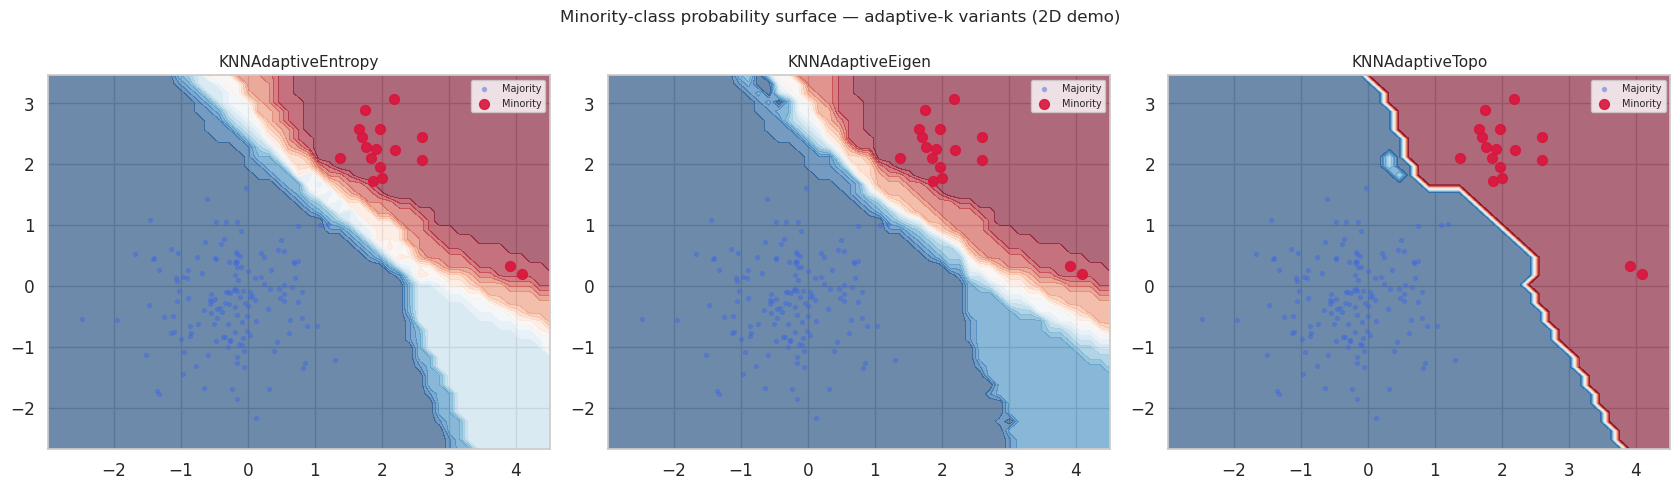

Colour = P(minority) for each grid point; note how boundaries differ across methods.


In [14]:
from src.algorithms import KNNAdaptiveEntropy, KNNAdaptiveEigen, KNNAdaptiveTopo
from src.algorithms import DANNAdaptive

# ── Demo: visualise which k each method selects on a 2D synthetic dataset ────
# Build an imbalanced 2D dataset with three structural zones:
#   - Dense majority region (centre-left)
#   - Small minority cluster (upper-right)
#   - Isolated minority outlier (far right)

rng_demo = np.random.default_rng(7)
X_maj  = rng_demo.multivariate_normal([0, 0],   [[1.0, 0], [0, 1.0]],  150)
X_min  = rng_demo.multivariate_normal([3, 3],   [[0.3, 0], [0, 0.3]],   15)
X_iso  = rng_demo.multivariate_normal([6, 0.5], [[0.1, 0], [0, 0.1]],    2)
X_demo = np.vstack([X_maj, X_min, X_iso])
y_demo = np.array([0]*150 + [1]*15 + [1]*2)

scaler_demo = StandardScaler()
X_demo_s = scaler_demo.fit_transform(X_demo)

variants = {
    "KNNAdaptiveEntropy": KNNAdaptiveEntropy(),
    "KNNAdaptiveEigen":   KNNAdaptiveEigen(),
    "KNNAdaptiveTopo":    KNNAdaptiveTopo(),
}
for clf in variants.values():
    clf.fit(X_demo_s, y_demo)

# ── Grid of query points — record selected k ─────────────────────────────────
h = 0.15
x_min_g, x_max_g = X_demo_s[:, 0].min() - 0.5, X_demo_s[:, 0].max() + 0.5
y_min_g, y_max_g = X_demo_s[:, 1].min() - 0.5, X_demo_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min_g, x_max_g, h), np.arange(y_min_g, y_max_g, h))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, clf) in zip(axes, variants.items()):
    # Predict (just to trigger k selection) — use predict_proba for minority score
    proba_grid = clf.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba_grid, levels=20, cmap="RdBu_r", alpha=0.6, vmin=0, vmax=1)
    ax.scatter(X_demo_s[y_demo==0, 0], X_demo_s[y_demo==0, 1],
               c="royalblue", s=8, alpha=0.4, label="Majority")
    ax.scatter(X_demo_s[y_demo==1, 0], X_demo_s[y_demo==1, 1],
               c="crimson", s=50, alpha=0.9, label="Minority")
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=7)

fig.suptitle("Minority-class probability surface — adaptive-k variants (2D demo)", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "adaptive_variants_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Colour = P(minority) for each grid point; note how boundaries differ across methods.")

---
## 5. Benchmarking and Comparison

All algorithms are evaluated under the same repeated stratified k-fold protocol:
- **Outer CV:** 5-fold stratified (1 repeat in quick mode, 5 in full mode)
- **Preprocessing:** StandardScaler fit on train fold, applied to test fold
- **Metrics:** F1 (minority class), balanced accuracy, G-mean, ROC-AUC

Algorithms compared:

| Name | Description |
|---|---|
| `KNNBaseline` | KNNClassifierFast with fixed k=5 |
| `KNNOptK` | CV-selected k (odd values 1..√n) |
| `KNNAdaptiveEntropy` | Per-point k via entropy hill-climb |
| `KNNAdaptiveEigen` | Per-point k via eigenvalue hill-climb |
| `KNNAdaptiveTopo` | Per-point k via persistent homology |
| `DANN` | DANN with fixed k=5 |
| `DANNAdaptive_entropy` | DANN + entropy hill-climb |
| `SMOTE+KNN` | SMOTE oversampling + KNNClassifierFast k=5 |

In [15]:
import shutil

# _bench_cache defined here so snapshot utilities work before the run cell executes
_bench_cache = TAB_DIR / "benchmark_raw.csv"

# ── Snapshot utilities ────────────────────────────────────────────────────────
# save_snapshot('v1_entropy_hill_climb')   # copy current results to a named file
# load_snapshot('v1_entropy_hill_climb')   # load a snapshot as a DataFrame
# list_snapshots()                         # show all saved snapshots
# reset_results()                          # delete benchmark_raw.csv for a fresh run

def save_snapshot(tag: str) -> None:
    if not _bench_cache.exists():
        print('Nothing to snapshot.')
        return
    dest = TAB_DIR / f'benchmark_{tag}.csv'
    shutil.copy(_bench_cache, dest)
    df = pd.read_csv(dest)
    print(f'Saved -> {dest.name}  ({df["algorithm"].nunique()} algs, {df["dataset"].nunique()} datasets)')

def load_snapshot(tag: str) -> pd.DataFrame:
    path = TAB_DIR / f'benchmark_{tag}.csv'
    if not path.exists():
        raise FileNotFoundError(f'No snapshot named "{tag}"')
    df = pd.read_csv(path)
    print(f'Loaded {path.name}  ({len(df)} rows)')
    return df

def list_snapshots() -> None:
    snaps = sorted(p for p in TAB_DIR.glob('benchmark_*.csv') if p.name != 'benchmark_raw.csv')
    if not snaps:
        print('No snapshots found.')
        return
    for p in snaps:
        try:
            df = pd.read_csv(p)
            algs = ', '.join(sorted(df['algorithm'].unique()))
            print(f'  {p.name:<45}  {df["dataset"].nunique():2d} datasets  [{algs}]')
        except Exception:
            print(f'  {p.name}  (unreadable)')

def reset_results() -> None:
    if _bench_cache.exists():
        _bench_cache.unlink()
        print('Deleted benchmark_raw.csv — next run will start fresh.')
    else:
        print('benchmark_raw.csv does not exist.')

print('Snapshot utilities ready.  Current snapshots:')
list_snapshots()


Snapshot utilities ready.  Current snapshots:
  benchmark_by_ir_quartile.csv  (unreadable)
  benchmark_raw_backup_20260421_095441.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_104142.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_164536.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_170153.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNFairRank, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_172121.csv       49 datasets  [DANN, DANNAdaptive_entrop

In [16]:
import time, os
from src.evaluation.benchmarking import run_benchmark
from src.algorithms import (KNNAdaptiveEntropy, KNNAdaptiveEigen, KNNAdaptiveTopo,
                             KNNAdaptiveDualAnchor, KNNFairRank, DANN, DANNAdaptive, KNNOptK, KNNClassifierFast)
from imblearn.over_sampling import SMOTE

# ── Run control ────────────────────────────────────────────────────────────────
# RUN_MODE : 'fast' = no DANN (exploratory), 'full' = all algorithms (final)
# N_JOBS   : outer dataset-level parallelism
#   - N_JOBS=1  → sequential, all inner jobs use full CPU budget
#   - N_JOBS=4  → 4 datasets in parallel, inner jobs share the budget
# Thread budget: N_JOBS * ALG_JOBS <= cpu_count  (handled automatically below)
RUN_MODE = 'full'
N_JOBS   = 4  # i9-7900X (20 logical cores): 4 outer x 5 inner = 20 threads
_cpu = os.cpu_count() or 4
ALG_JOBS   = max(1, _cpu // max(1, N_JOBS))   # per-point predict parallelism
KOPTK_JOBS = max(1, _cpu // max(1, N_JOBS))   # KNNOptK inner CV parallelism
print(f'CPUs: {_cpu}  |  N_JOBS={N_JOBS}  |  ALG_JOBS={ALG_JOBS}  |  KOPTK_JOBS={KOPTK_JOBS}')

# ── Estimator wrappers ─────────────────────────────────────────────────────────
class KNNBaseline(KNNClassifierFast):
    def __init__(self): super().__init__(k=5)

class KNNOptKBench(KNNOptK):
    def __init__(self): super().__init__(n_jobs=KOPTK_JOBS)

class KNNAdaptiveEntropyBench(KNNAdaptiveEntropy):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveEigenBench(KNNAdaptiveEigen):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveTopoBench(KNNAdaptiveTopo):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveDualAnchorBench(KNNAdaptiveDualAnchor):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankBench(KNNFairRank):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class DANNBench(DANN):
    def __init__(self): super().__init__(k=5, n_jobs=ALG_JOBS)

class DANNAdaptiveEntropyBench(DANNAdaptive):
    def __init__(self): super().__init__(adaptation_strategy='entropy', n_jobs=ALG_JOBS)

class SMOTEKNNClassifier:
    def __init__(self): self._clf = None
    def fit(self, X, y):
        n_minority = int(y.sum())
        k_sm = max(1, min(5, n_minority - 1))
        try:
            X_res, y_res = SMOTE(k_neighbors=k_sm, random_state=SEED).fit_resample(X, y)
        except Exception:
            X_res, y_res = X, y
        self._clf = KNNClassifierFast(k=5)
        self._clf.fit(X_res, y_res)
        self.classes_ = self._clf.classes_
        return self
    def predict(self, X): return self._clf.predict(X)
    def predict_proba(self, X): return self._clf.predict_proba(X)

# ── Algorithm sets ─────────────────────────────────────────────────────────────
ESTIMATORS_FAST = {
    'KNNBaseline':           KNNBaseline,
    'KNNOptK':               KNNOptKBench,
    'KNNAdaptiveEntropy':    KNNAdaptiveEntropyBench,
    'KNNAdaptiveEigen':      KNNAdaptiveEigenBench,
    'KNNAdaptiveTopo':       KNNAdaptiveTopoBench,
    'KNNAdaptiveDualAnchor': KNNAdaptiveDualAnchorBench,
    'KNNFairRank':           KNNFairRankBench,
    'SMOTE+KNN':             SMOTEKNNClassifier,
}
ESTIMATORS_FULL = {
    **ESTIMATORS_FAST,
    'DANN':                 DANNBench,
    'DANNAdaptive_entropy': DANNAdaptiveEntropyBench,
}

ESTIMATORS = ESTIMATORS_FAST if RUN_MODE == 'fast' else ESTIMATORS_FULL
print(f'Mode: {RUN_MODE}  |  Algorithms: {list(ESTIMATORS)}')

t0 = time.perf_counter()
bench_df = run_benchmark(ESTIMATORS, datasets, output_path=_bench_cache, n_jobs=N_JOBS)
elapsed = time.perf_counter() - t0

print(f'\nTotal time: {elapsed/60:.1f} min  |  {len(bench_df)} rows')
print(bench_df.groupby('algorithm').size().rename('folds').to_string())

CPUs: 16  |  N_JOBS=4  |  ALG_JOBS=4  |  KOPTK_JOBS=4
Mode: full  |  Algorithms: ['KNNBaseline', 'KNNOptK', 'KNNAdaptiveEntropy', 'KNNAdaptiveEigen', 'KNNAdaptiveTopo', 'KNNAdaptiveDualAnchor', 'KNNFairRank', 'SMOTE+KNN', 'DANN', 'DANNAdaptive_entropy']
  Resuming: 490 (dataset, algorithm) pairs already done (49 datasets fully complete, 0 partially/not started).
  All combinations already complete — loading from cache.

Total time: 0.0 min  |  4900 rows
algorithm
DANN                     490
DANNAdaptive_entropy     490
KNNAdaptiveDualAnchor    490
KNNAdaptiveEigen         490
KNNAdaptiveEntropy       490
KNNAdaptiveTopo          490
KNNBaseline              490
KNNFairRank              490
KNNOptK                  490
SMOTE+KNN                490


In [17]:
# ── Load benchmark results from cache ────────────────────────────────────────
bench_df = pd.read_csv(_bench_cache)
print(f"Loaded {len(bench_df)} rows, {bench_df['dataset'].nunique()} datasets, "
      f"{bench_df['algorithm'].nunique()} algorithms")

# ── Filter out degenerate datasets (too few minority samples for reliable CV) ─
min_minority = 2 * cfg["evaluation"]["cv_folds"]
valid_datasets = [
    ds.name for ds in datasets
    if int(binarise_labels(ds.y).sum()) >= min_minority
]
removed = bench_df[~bench_df["dataset"].isin(valid_datasets)]["dataset"].unique()
bench_df = bench_df[bench_df["dataset"].isin(valid_datasets)].reset_index(drop=True)
print(f"Removed {len(removed)} degenerate datasets: {list(removed)}")
print(f"Remaining: {bench_df['dataset'].nunique()} datasets")


Loaded 4900 rows, 49 datasets, 10 algorithms
Removed 9 degenerate datasets: ['dataset_1013_analcatdata_challenger', 'dataset_1045_kc1-top5', 'dataset_1059_ar1', 'dataset_1064_ar6', 'dataset_450_analcatdata_lawsuit', 'dataset_865_analcatdata_neavote', 'dataset_950_arsenic-female-lung', 'dataset_951_arsenic-male-lung', 'dataset_875_analcatdata_chlamydia']
Remaining: 40 datasets


---
## 5.0 Metrics for Imbalanced Binary Classification — Interpretation Guide

Before reading the benchmark tables, it is important to understand *what each metric measures* and *why metric choice matters under class imbalance*. The four metrics we track below each reward different things, and the "best" algorithm can change depending on which metric you privilege.

### 5.0.1 The Failure of Accuracy

Plain accuracy is unusable here. With 99% majority / 1% minority (common in our dataset collection), a trivial classifier that always predicts majority scores 99% accuracy — yet has zero diagnostic value. Every metric below is designed to not be fooled by this.

### 5.0.2 Building Blocks: The Confusion Matrix

For binary classification with the minority class as the "positive" class:

|  | Predicted minority | Predicted majority |
|---|---|---|
| **Actual minority** | TP (true positive) | FN (false negative) |
| **Actual majority** | FP (false positive) | TN (true negative) |

From these we derive the two class-specific recall rates:

$$\text{TPR} \ (\text{sensitivity, minority recall}) = \frac{TP}{TP + FN}, \qquad \text{TNR} \ (\text{specificity, majority recall}) = \frac{TN}{TN + FP}$$

and minority-class precision:

$$\text{Precision} = \frac{TP}{TP + FP}$$

Every metric below is built from these three.

---

### 5.0.3 F1 Score

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{TPR}}{\text{Precision} + \text{TPR}}$$

**What it measures:** the harmonic mean of minority-class precision and recall. Rewards correctly identifying minority samples (recall) *without* over-predicting minority (precision).

**Crucial property:** $F_1$ depends only on TP, FP, and FN. **It does not use TN at all.** Correctly classifying a majority sample as majority does not improve $F_1$.

**Strengths:**
- Penalises both missed minority samples (low recall) and spurious minority flips (low precision).
- Standard in information retrieval, medical diagnosis, and any setting where false positives on the minority class are expensive.

**Weaknesses in imbalance context:**
- Hypersensitive to minority-class precision. With rare events (IR $\ll$ 1), a few false positives can tank precision even when overall classification is accurate. Example: 5/100 minority, classifier catches 4 true + 11 false → precision 4/15 = 0.27, $F_1 \approx 0.40$, even though the classifier is correct on 88/100 samples.
- **Asymmetric in the classes**: swapping labels changes the score. This is a feature for information retrieval but a bug for "which class is harder?" evaluations.

---

### 5.0.4 Balanced Accuracy (BA)

$$\text{BA} = \frac{\text{TPR} + \text{TNR}}{2}$$

**What it measures:** the arithmetic mean of minority recall and majority recall. Each class contributes equally regardless of sample count.

**Key property:** a classifier that always predicts majority scores $\text{BA} = 0.5$ (TPR=0, TNR=1). So the trivial-classifier failure mode of plain accuracy is gone.

**Strengths:**
- Symmetric in the classes — penalises equally ignoring either class.
- Simple interpretation: average per-class recall.
- Not affected by class frequencies — a rare class and a common class contribute equally.

**Weaknesses:**
- Treats a TPR=1.0 / TNR=0.0 classifier ("always predict minority") the same as a TPR=0.5 / TNR=0.5 classifier (random). Both give BA=0.5.
- Does not penalise asymmetry between the two recalls.

---

### 5.0.5 Geometric Mean (G-mean)

$$\text{G-mean} = \sqrt{\text{TPR} \cdot \text{TNR}}$$

**What it measures:** the geometric mean of both per-class recalls. Like BA but with a much stronger penalty for asymmetry.

**Key property:** if either TPR or TNR is zero, $\text{G-mean} = 0$. Unlike BA, you cannot compensate for catastrophically missing one class by over-performing on the other.

**Strengths:**
- Forces the classifier to perform reasonably on *both* classes — a single collapsed recall tanks the score.
- Introduced specifically for imbalanced classification (Kubat & Matwin 1997).
- Standard metric in the class-imbalance literature.

**Weaknesses:**
- Harder to interpret intuitively than BA.
- Near the degenerate "always predict minority" boundary, small changes in TNR produce large changes in score (the $\sqrt{\cdot}$ is steep near 0).

---

### 5.0.6 ROC AUC

$$\text{ROC AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d\text{FPR}$$

**What it measures:** the probability that a randomly chosen minority sample is ranked higher than a randomly chosen majority sample, across all possible decision thresholds. It evaluates the *ranking quality* of the classifier's probability scores, not its hard-label decisions.

**Key property:** threshold-independent. ROC AUC is high if the classifier reliably assigns higher probabilities to minority than to majority samples, even if the default 0.5 threshold produces bad hard labels.

**Strengths:**
- Captures the classifier's underlying discrimination ability independent of any threshold.
- Useful when the final threshold will be tuned for the application.
- Not fooled by class frequency.

**Weaknesses:**
- Does not reflect hard-label performance. A classifier with high AUC can still produce useless hard predictions at the default threshold.
- Can be **misleading under severe imbalance**: a random majority sample is easy to rank above a random minority sample *because majority is so common*. Precision-Recall AUC is often preferred for this reason.
- Requires `predict_proba` — not all classifiers produce well-calibrated probabilities.

---

### 5.0.7 Which Metric Is "Best" for This Project?

We are solving a **binary classification problem with severe class imbalance**, and the *goal of the algorithms* is to correct for that imbalance by better identifying minority samples. The right metric must:

1. **Not be fooled by always-predict-majority.** Rules out plain accuracy.
2. **Treat both classes symmetrically.** Our algorithms are designed to balance class-conditional performance, not to optimise minority precision specifically.
3. **Reflect hard-label classifier quality** (not just ranking).
4. **Be standard in the imbalance literature** so results are comparable.

| Metric | Criterion 1 | Criterion 2 | Criterion 3 | Criterion 4 |
|---|---|---|---|---|
| Accuracy | ✗ | ✓ | ✓ | — |
| $F_1$ | ✓ | **✗ (asymmetric)** | ✓ | ✓ |
| BA | ✓ | ✓ | ✓ | ✓ |
| **G-mean** | ✓ | ✓ | ✓ | ✓✓ |
| ROC AUC | ✓ | ✓ | **✗ (ranking only)** | ✓ |

**G-mean is the best single metric for this setting.** It meets all four criteria and additionally punishes asymmetry, which is what we want: an algorithm that catches minority samples by sacrificing all majority classification is not actually solving the problem.

**BA is a close second and more interpretable** — use it when communicating to readers unfamiliar with G-mean.

**$F_1$ should be reported but not used as the sole criterion.** It is the standard metric outside the imbalance literature, so including it makes results comparable to broader ML work. But within imbalance-focused work, $F_1$ systematically penalises algorithms that trade minority-class precision for balanced recall — which is exactly what well-designed imbalance-aware algorithms do.

**ROC AUC complements the hard-label metrics** by showing ranking quality. It is useful for diagnosing whether a classifier with low $F_1$/BA has good underlying discrimination that a better threshold could unlock.

---

### 5.0.8 How to Read the Tables Below

When the tables show different leaders per metric:

- **Best on $F_1$ but not on G-mean/BA:** algorithm is conservative — good minority precision but may be missing minority samples that better-recall algorithms would catch.
- **Best on G-mean/BA but not on $F_1$:** algorithm has balanced per-class recall but sacrifices minority precision — flips more majority samples to minority than strictly needed.
- **Best on ROC AUC but not on hard-label metrics:** algorithm ranks samples well but its default threshold is miscalibrated — a threshold-tuning step could unlock better $F_1$/BA.

**In this benchmark, we report all four metrics** because no single number tells the whole story, and different downstream applications would weight them differently.

In [18]:
# ── 5.1  Overall mean metrics per algorithm ──────────────────────────────────
# Primary ordering is by G-mean (the canonical metric for imbalanced classification;
# see section 5.0). F1 is reported alongside for reference — but under imbalance,
# F1 systematically penalises algorithms that trade minority-precision for
# balanced recall, which is exactly what well-designed imbalance-aware methods do.

METRICS = ["f1", "balanced_accuracy", "geometric_mean", "roc_auc"]

summary_table = (
    bench_df
    .groupby("algorithm")[METRICS]
    .mean()
    .round(4)
    .sort_values("geometric_mean", ascending=False)
)
summary_table.to_csv(TAB_DIR / "benchmark_summary.csv")

# Delta vs KNNOptK (fair comparison baseline for adaptive-k methods)
optk_means = summary_table.loc["KNNOptK"]
delta_table = (summary_table - optk_means).round(4)
delta_table.columns = [f"Δ_{c}" for c in delta_table.columns]

display_table = pd.concat([summary_table, delta_table], axis=1)
print("Mean metrics across all datasets (sorted by G-mean — primary metric for imbalance):")
print("(Δ columns show difference vs KNNOptK — the fair comparison baseline)")
print(display_table.to_string())

# Show leaders per metric
print("\nPer-metric leaders:")
for m in METRICS:
    leader = summary_table[m].idxmax()
    leader_val = summary_table.loc[leader, m]
    print(f"  {m:<22}  →  {leader:<24}  ({leader_val:.4f})")
display_table

Mean metrics across all datasets (sorted by G-mean — primary metric for imbalance):
(Δ columns show difference vs KNNOptK — the fair comparison baseline)
                           f1  balanced_accuracy  geometric_mean  roc_auc    Δ_f1  Δ_balanced_accuracy  Δ_geometric_mean  Δ_roc_auc
algorithm                                                                                                                          
KNNFairRank            0.5367             0.8316          0.8202   0.8639 -0.0146               0.0789            0.1852     0.0838
SMOTE+KNN              0.5527             0.7922          0.7705   0.8206  0.0014               0.0395            0.1355     0.0405
KNNAdaptiveTopo        0.5615             0.7555          0.6623   0.7557  0.0102               0.0028            0.0273    -0.0244
KNNOptK                0.5513             0.7527          0.6350   0.7801  0.0000               0.0000            0.0000     0.0000
KNNAdaptiveDualAnchor  0.5320             0.7384      

,f1,balanced_accuracy,geometric_mean,roc_auc,Δ_f1,Δ_balanced_accuracy,Δ_geometric_mean,Δ_roc_auc
algorithm,,,,,,,,
KNNFairRank,0.5367,0.8316,0.8202,0.8639,-0.0146,0.0789,0.1852,0.0838
SMOTE+KNN,0.5527,0.7922,0.7705,0.8206,0.0014,0.0395,0.1355,0.0405
KNNAdaptiveTopo,0.5615,0.7555,0.6623,0.7557,0.0102,0.0028,0.0273,-0.0244
KNNOptK,0.5513,0.7527,0.6350,0.7801,0.0000,0.0000,0.0000,0.0000
KNNAdaptiveDualAnchor,0.5320,0.7384,0.5887,0.8620,-0.0193,-0.0143,-0.0463,0.0819
KNNBaseline,0.5244,0.7360,0.5830,0.8114,-0.0269,-0.0167,-0.0520,0.0313
KNNAdaptiveEntropy,0.4679,0.7085,0.5165,0.8423,-0.0834,-0.0442,-0.1185,0.0622
KNNAdaptiveEigen,0.4277,0.6931,0.4601,0.8492,-0.1236,-0.0596,-0.1749,0.0691
DANN,0.3007,0.6124,0.3854,0.6828,-0.2506,-0.1403,-0.2496,-0.0973


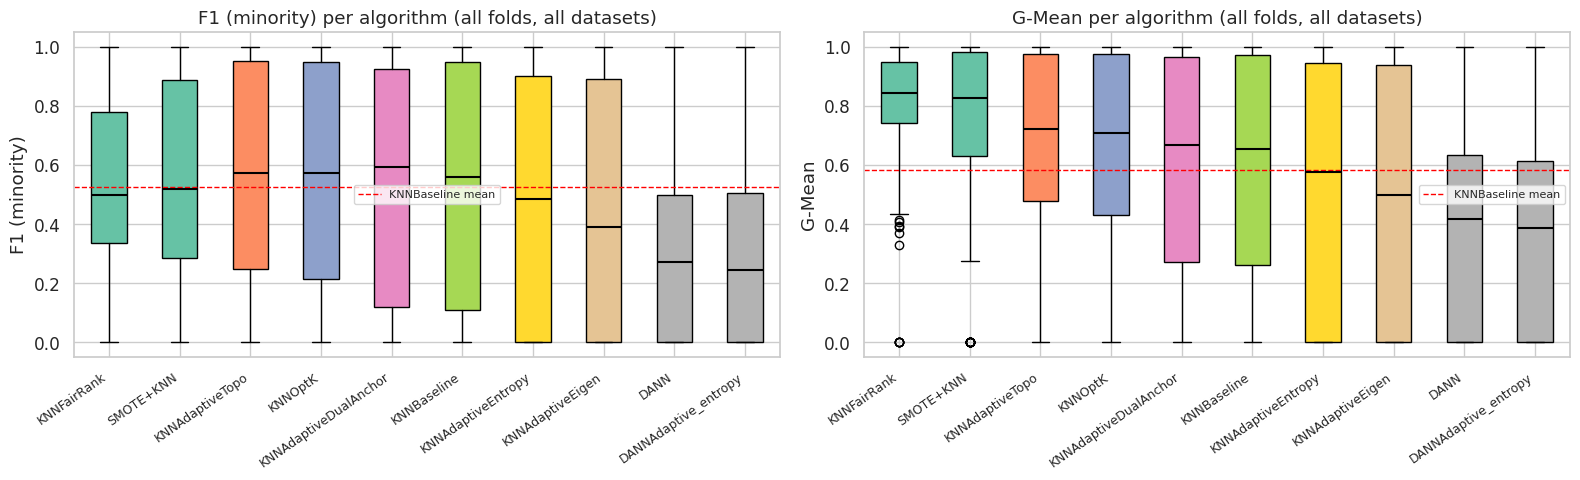

In [19]:
# ── 5.2  Boxplots: per-fold F1 and G-mean distribution per algorithm ─────────

ALG_ORDER = summary_table.index.tolist()  # sorted by mean F1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    data_plot = [bench_df[bench_df["algorithm"] == alg][metric].dropna().values for alg in ALG_ORDER]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=1.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(ALG_ORDER)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_xticks(range(1, len(ALG_ORDER) + 1))
    ax.set_xticklabels(ALG_ORDER, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(f"{label} per algorithm (all folds, all datasets)")
    ax.axhline(summary_table.loc["KNNBaseline", metric], color="red",
               linestyle="--", linewidth=1, label="KNNBaseline mean")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

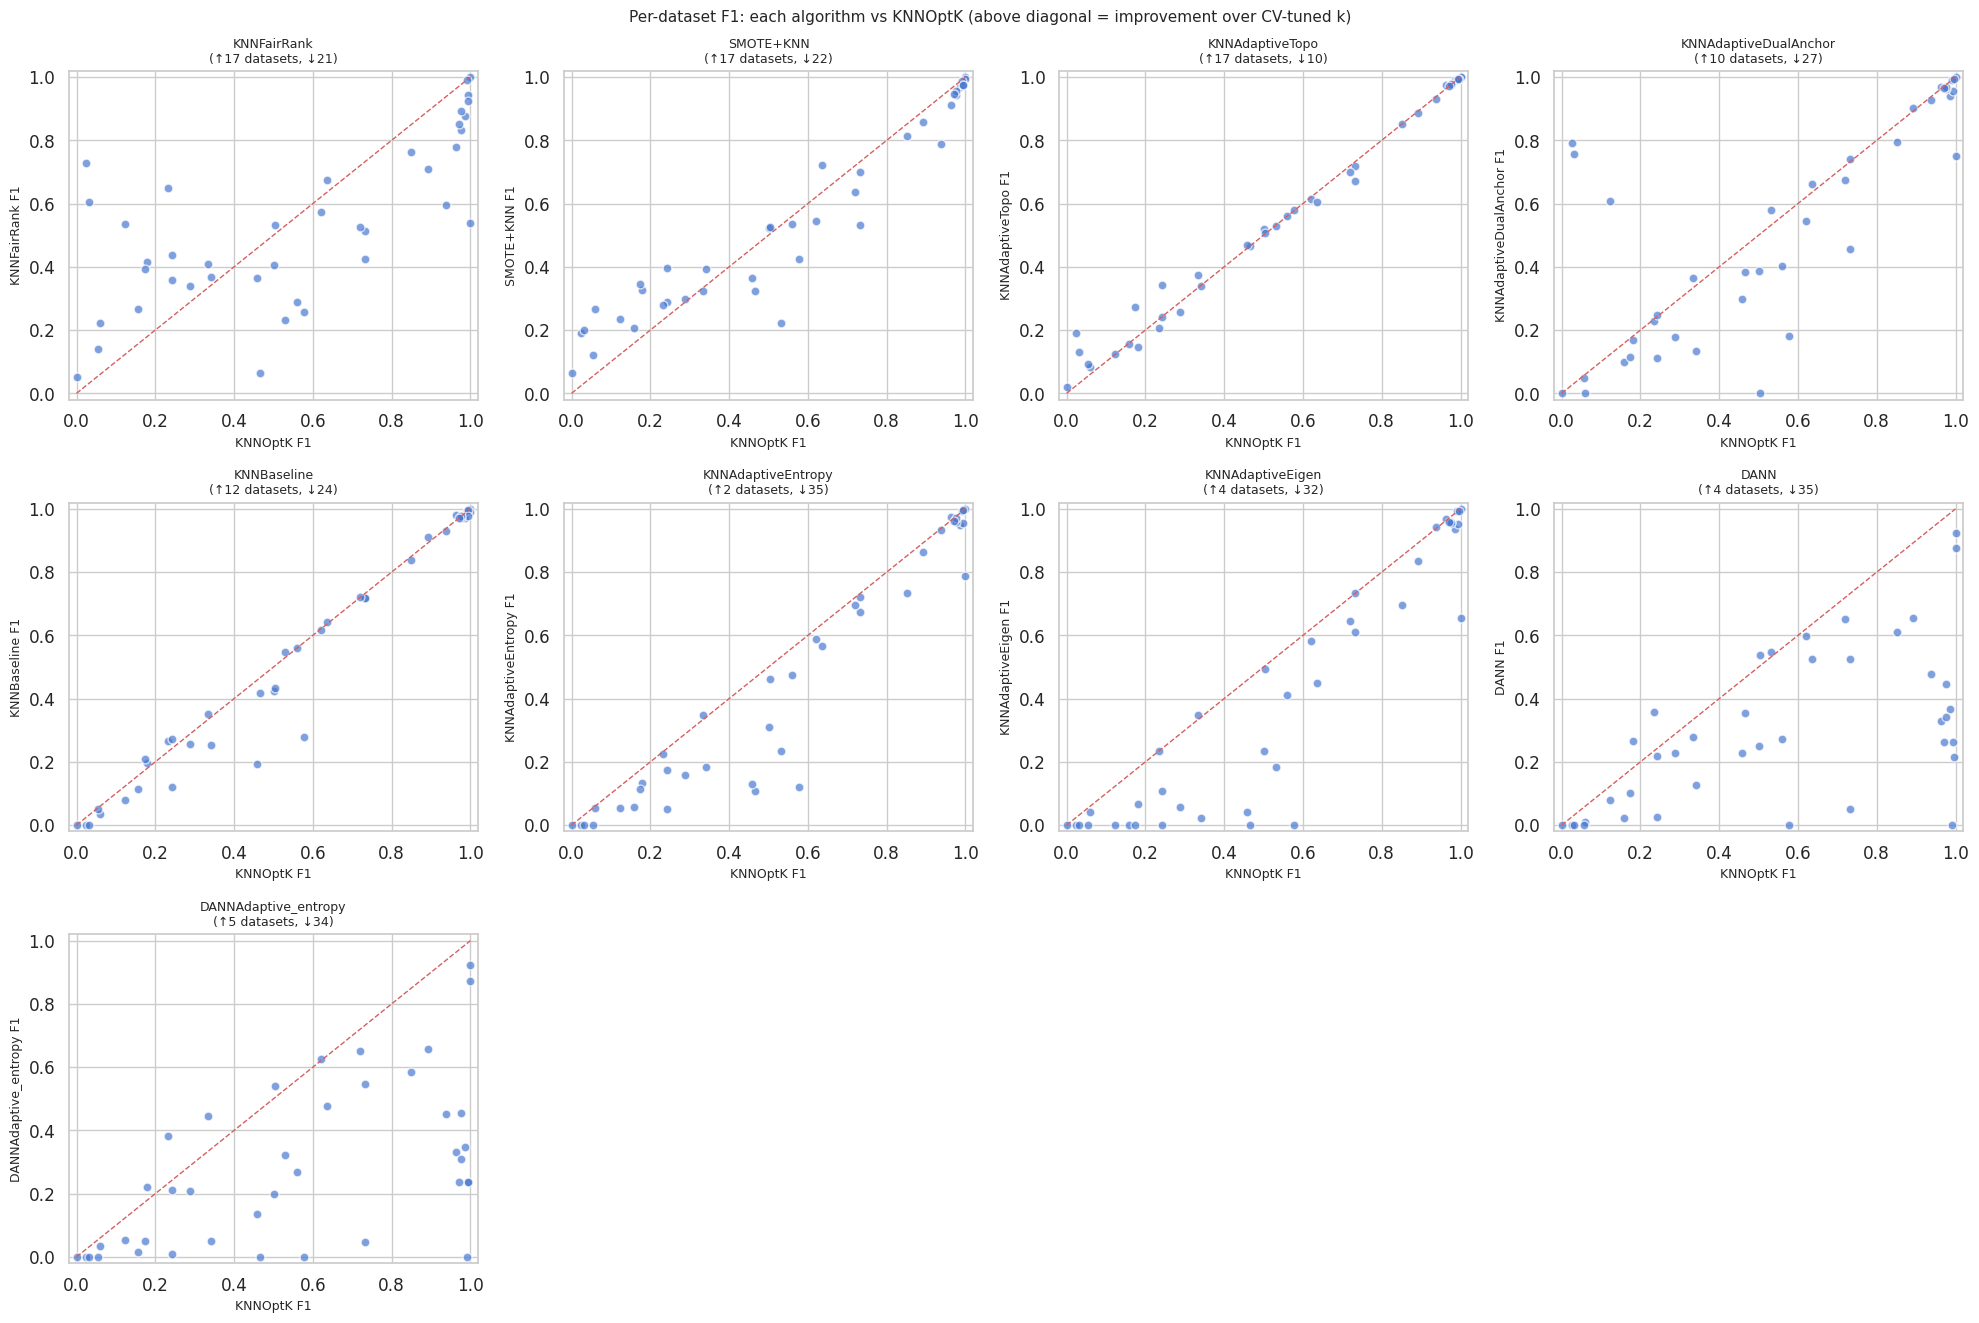

In [20]:
# ── 5.3  Per-dataset F1 scatter: each algorithm vs KNNOptK ───────────────
# KNNOptK is the fair comparison baseline: it already uses data-driven k selection,
# so improvements over it reflect the value of per-point adaptive-k strategies.

per_ds_alg = (
    bench_df
    .groupby(["dataset", "algorithm"])["f1"]
    .mean()
    .unstack("algorithm")
)

competitors = [a for a in ALG_ORDER if a != "KNNOptK"]
n_cols = 4
n_rows = int(np.ceil(len(competitors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.ravel()

for ax, alg in zip(axes, competitors):
    x = per_ds_alg["KNNOptK"]
    y_alg = per_ds_alg[alg]
    wins = (y_alg > x).sum()
    losses = (y_alg < x).sum()
    ax.scatter(x, y_alg, alpha=0.7, edgecolors="white", s=40)
    ax.plot([0, 1], [0, 1], "r--", linewidth=1)
    ax.set_xlabel("KNNOptK F1", fontsize=9)
    ax.set_ylabel(f"{alg} F1", fontsize=9)
    ax.set_title(f"{alg}\n(↑{wins} datasets, ↓{losses})", fontsize=9)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

for ax in axes[len(competitors):]:
    ax.set_visible(False)

fig.suptitle("Per-dataset F1: each algorithm vs KNNOptK (above diagonal = improvement over CV-tuned k)", fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_scatter_vs_optk.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_40973/2918297954.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["IR_quartile", "algorithm"])["f1"]
/tmp/ipykernel_40973/2918297954.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["IR_quartile", "algorithm"])["geometric_mean"]


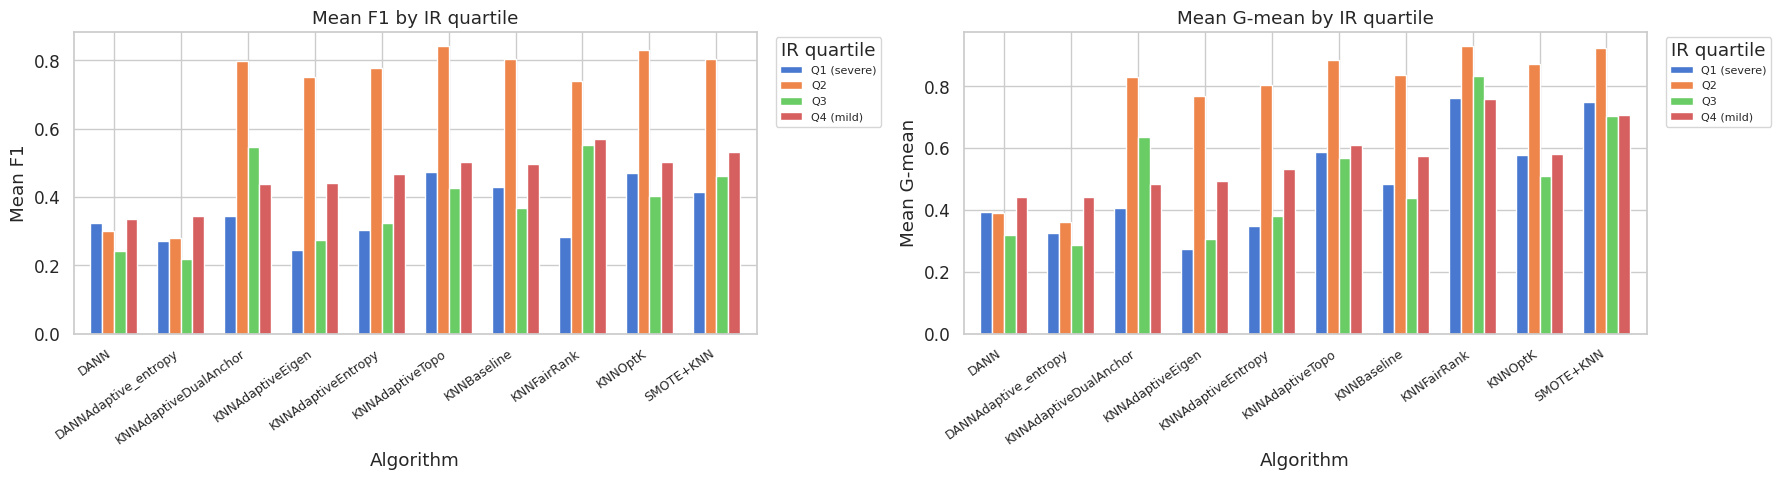

F1 by IR quartile:
algorithm      DANN  DANNAdaptive_entropy  KNNAdaptiveDualAnchor  KNNAdaptiveEigen  KNNAdaptiveEntropy  KNNAdaptiveTopo  KNNBaseline  KNNFairRank  KNNOptK  SMOTE+KNN
IR_quartile                                                                                                                                                          
Q1 (severe)  0.3245                0.2701                 0.3445            0.2443              0.3043           0.4739       0.4295       0.2836   0.4699     0.4141
Q2           0.3013                0.2793                 0.7984            0.7504              0.7767           0.8411       0.8054       0.7408   0.8289     0.8034
Q3           0.2420                0.2189                 0.5473            0.2742              0.3239           0.4273       0.3675       0.5523   0.4041     0.4618
Q4 (mild)    0.3351                0.3454                 0.4379            0.4419              0.4666           0.5038       0.4952       0.5701   0.5

In [21]:
# ── 5.4  Performance by imbalance severity (IR quartiles) ────────────────────
# We report both F1 and G-mean per IR quartile. The two can diverge: an algorithm
# may trade minority-precision for balanced recall, hurting F1 but helping G-mean.

bench_df["IR_quartile"] = pd.qcut(bench_df["imbalance_ratio"], q=4,
                                   labels=["Q1 (severe)", "Q2", "Q3", "Q4 (mild)"])

ir_summary_f1 = (
    bench_df
    .groupby(["IR_quartile", "algorithm"])["f1"]
    .mean()
    .unstack("algorithm")
    .round(4)
)
ir_summary_gmean = (
    bench_df
    .groupby(["IR_quartile", "algorithm"])["geometric_mean"]
    .mean()
    .unstack("algorithm")
    .round(4)
)
ir_summary_f1.to_csv(TAB_DIR / "benchmark_by_ir_quartile.csv")
ir_summary_gmean.to_csv(TAB_DIR / "benchmark_by_ir_quartile_gmean.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, tbl, label in zip(axes, [ir_summary_f1, ir_summary_gmean], ["F1", "G-mean"]):
    tbl.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(f"Mean {label} by IR quartile")
    ax.legend(title="IR quartile", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_by_ir_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

print("F1 by IR quartile:")
print(ir_summary_f1.to_string())
print()
print("G-mean by IR quartile (primary metric for imbalanced classification):")
print(ir_summary_gmean.to_string())
print()
print("Interpretation: compare the quartile winners across the two metrics.")
print("Algorithms that lead on G-mean but not F1 are trading minority-precision for balanced recall.")


### 5.5  Bootstrap Confidence Intervals — Predicting Final-Run Results

The current benchmark covers a subset of datasets and/or repetitions.
To estimate where the **full-run mean metric** will land, we use **non-parametric bootstrap resampling** over datasets:

1. Compute the per-dataset mean metric for each algorithm (averaging over all folds and repeats).
2. Draw B = 2000 bootstrap samples (resample datasets *with replacement*, same size as the current set).
3. Recompute the mean for each bootstrap sample → distribution of the bootstrapped mean.
4. The 2.5th and 97.5th percentiles form the **95% CI**.

**Interpretation:** with 95% confidence, the mean metric on the full dataset pool will fall within this interval,
assuming the current datasets are a representative sample of the broader benchmark.
Algorithms with narrow CIs are stable across datasets; wide CIs signal high dataset-to-dataset variability.

In [22]:
# ── 5.5a  Bootstrap CI — table (F1 and G-mean) ────────────────────────────────

B_BOOT = 2000
ALPHA_CI = 0.05
rng_ci = np.random.default_rng(SEED)

per_ds_metric = bench_df.groupby(["dataset", "algorithm"])[METRICS].mean()

ci_rows = []
for metric in METRICS:
    pivot = per_ds_metric[metric].unstack("algorithm")
    for alg in pivot.columns:
        vals = pivot[alg].dropna().values
        n = len(vals)
        obs_mean = vals.mean()
        boot_means = np.array([
            rng_ci.choice(vals, size=n, replace=True).mean()
            for _ in range(B_BOOT)
        ])
        lo = np.percentile(boot_means, 100 * ALPHA_CI / 2)
        hi = np.percentile(boot_means, 100 * (1 - ALPHA_CI / 2))
        ci_rows.append({
            "algorithm": alg, "metric": metric,
            "mean": round(obs_mean, 4),
            "ci_lower": round(lo, 4),
            "ci_upper": round(hi, 4),
            "ci_width": round(hi - lo, 4),
            "n_datasets": n,
        })

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(TAB_DIR / "bootstrap_ci.csv", index=False)

for metric, label in [("geometric_mean", "G-mean (primary metric for imbalance)"), ("f1", "F1 (secondary — penalises low minority-precision)")]:
    m_ci = (
        ci_df[ci_df["metric"] == metric]
        .set_index("algorithm")
        .sort_values("mean", ascending=False)
    )
    n_ds = int(m_ci["n_datasets"].iloc[0])
    print(f"\nBootstrap 95% CI — {label}  (B={B_BOOT}, {n_ds} datasets)")
    print("{:<28} {:>9} {:>22}  {:>8}".format("Algorithm", "Mean", "95% CI", "Width"))
    print("-" * 72)
    for alg, row in m_ci.iterrows():
        ci_str = "[{:.4f}, {:.4f}]".format(row["ci_lower"], row["ci_upper"])
        print("{:<28} {:>9.4f} {:>22}  {:>8.4f}".format(alg, row["mean"], ci_str, row["ci_width"]))

print("\nNote: CIs reflect uncertainty from the current dataset sample.")
print("Overlapping CIs indicate the algorithms are not statistically distinguishable on that metric.")


Bootstrap 95% CI — G-mean (primary metric for imbalance)  (B=2000, 40 datasets)
Algorithm                         Mean                 95% CI     Width
------------------------------------------------------------------------
KNNFairRank                     0.8202       [0.7746, 0.8618]    0.0872
SMOTE+KNN                       0.7705       [0.7071, 0.8321]    0.1250
KNNAdaptiveTopo                 0.6623       [0.5732, 0.7502]    0.1770
KNNOptK                         0.6350       [0.5334, 0.7363]    0.2029
KNNAdaptiveDualAnchor           0.5887       [0.4758, 0.6882]    0.2124
KNNBaseline                     0.5830       [0.4774, 0.6912]    0.2138
KNNAdaptiveEntropy              0.5165       [0.4020, 0.6344]    0.2324
KNNAdaptiveEigen                0.4601       [0.3316, 0.5837]    0.2521
DANN                            0.3854       [0.3055, 0.4705]    0.1650
DANNAdaptive_entropy            0.3536       [0.2721, 0.4454]    0.1733

Bootstrap 95% CI — F1 (secondary — penalises low mino

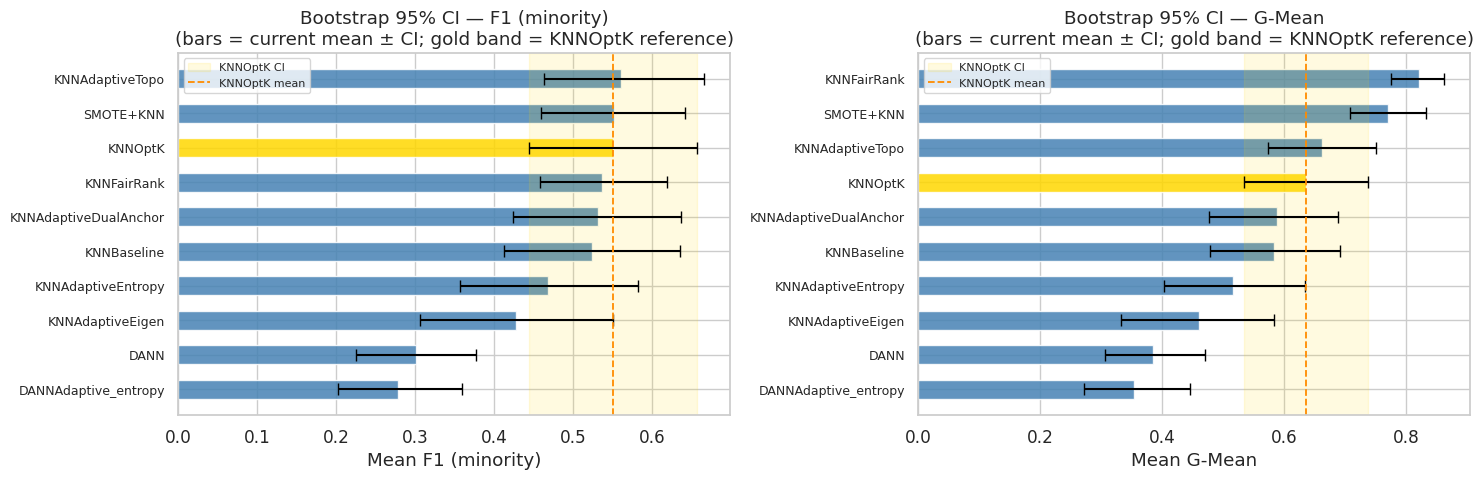

Gold band = KNNOptK 95% CI (reference). Algorithms whose CI does not overlap
with KNNOptK's band are likely to show a meaningful difference in the final run.


In [23]:
# ── 5.5b  Bootstrap CI — forest plot ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    m_ci = (
        ci_df[ci_df["metric"] == metric]
        .set_index("algorithm")
        .sort_values("mean", ascending=False)
    )
    algs = m_ci.index.tolist()
    y = np.arange(len(algs))
    colors = ["gold" if a == "KNNOptK" else "steelblue" for a in algs]

    ax.barh(y, m_ci["mean"],
            xerr=[m_ci["mean"] - m_ci["ci_lower"], m_ci["ci_upper"] - m_ci["mean"]],
            height=0.55, capsize=4, color=colors, ecolor="black", alpha=0.85)

    # Shade KNNOptK CI as the reference band
    if "KNNOptK" in m_ci.index:
        optk_lo = m_ci.loc["KNNOptK", "ci_lower"]
        optk_hi = m_ci.loc["KNNOptK", "ci_upper"]
        ax.axvspan(optk_lo, optk_hi, alpha=0.12, color="gold", label="KNNOptK CI")
        ax.axvline(m_ci.loc["KNNOptK", "mean"], color="darkorange",
                   linestyle="--", linewidth=1.3, label="KNNOptK mean")

    ax.set_yticks(y)
    ax.set_yticklabels(algs, fontsize=9)
    ax.set_xlabel(f"Mean {label}")
    ax.set_title(
        f"Bootstrap 95% CI — {label}\n"
        "(bars = current mean ± CI; gold band = KNNOptK reference)"
    )
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "bootstrap_ci_forest.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gold band = KNNOptK 95% CI (reference). Algorithms whose CI does not overlap")
print("with KNNOptK's band are likely to show a meaningful difference in the final run.")


---
## 6. Statistical Analysis

Following Demšar (2006), we use non-parametric tests to determine whether performance differences are statistically significant across the benchmark:

1. **Friedman test** — global null: all algorithms perform equally.  A significant result (p < 0.05) justifies pairwise comparisons.
2. **Pairwise Wilcoxon signed-rank tests with Holm correction** — each algorithm vs **KNNOptK**.  KNNOptK is the fair comparison baseline because it already uses cross-validated k selection; any improvement over it reflects the value of per-point adaptive-k strategies.  Holm controls the family-wise error rate.
3. **Average ranks** — lower = better across datasets.  The critical difference (Nemenyi, α=0.05) is computed; pairs within CD are not statistically distinguishable.

In [24]:
from src.evaluation.statistical_tests import friedman_test, pairwise_wilcoxon, average_ranks, critical_difference

# ── 6.1  Friedman test ────────────────────────────────────────────────────────
for metric in ["f1", "balanced_accuracy", "geometric_mean"]:
    stat, p = friedman_test(bench_df, metric=metric)
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"Friedman  {metric:<22}  χ²={stat:.3f}  p={p:.4f}  [{sig}]")

Friedman  f1                      χ²=119.779  p=0.0000  [✓ significant]
Friedman  balanced_accuracy       χ²=140.427  p=0.0000  [✓ significant]
Friedman  geometric_mean          χ²=192.180  p=0.0000  [✓ significant]


In [25]:
# ── 6.2  Pairwise Wilcoxon with Holm correction (vs KNNOptK) ──────────────
# We test on both F1 (for continuity with general ML literature) and G-mean
# (the canonical imbalance metric, where algorithm differences are often clearer).

for metric, label in [("geometric_mean", "G-mean"), ("f1", "F1")]:
    wilcox = pairwise_wilcoxon(bench_df, baseline="KNNOptK", metric=metric)
    wilcox.to_csv(TAB_DIR / f"wilcoxon_vs_optk_{metric}.csv", index=False)

    print(f"\nPairwise Wilcoxon ({label}) vs KNNOptK — Holm corrected:")
    print(wilcox.to_string(index=False))

    sig = wilcox[wilcox["significant"]]
    per_ds = bench_df.groupby(["dataset", "algorithm"])[metric].mean().unstack()
    for _, row in sig.iterrows():
        alg = row["algorithm"]
        delta = (per_ds[alg] - per_ds["KNNOptK"]).mean()
        direction = "BETTER" if delta > 0 else "WORSE"
        p_cor = row["p_corrected"]
        print(f"  {alg}: mean Δ={delta:+.4f} → {direction} than KNNOptK (p_corrected={p_cor:.4f})")

# Save F1 version under legacy filename for compatibility with any external scripts
wilcox_f1 = pairwise_wilcoxon(bench_df, baseline="KNNOptK", metric="f1")
wilcox_f1.to_csv(TAB_DIR / "wilcoxon_vs_optk.csv", index=False)


Pairwise Wilcoxon (G-mean) vs KNNOptK — Holm corrected:
            algorithm  statistic        p_raw  p_corrected  significant
     KNNAdaptiveEigen        3.0 2.166071e-07     0.000002         True
   KNNAdaptiveEntropy       10.0 2.577690e-07     0.000002         True
                 DANN       46.0 1.582547e-06     0.000011         True
            SMOTE+KNN       46.0 1.582547e-06     0.000009         True
 DANNAdaptive_entropy       49.0 1.948879e-06     0.000010         True
          KNNFairRank       84.0 3.254270e-05     0.000130         True
          KNNBaseline       90.0 1.347181e-04     0.000404         True
      KNNAdaptiveTopo       53.0 1.085403e-03     0.002171         True
KNNAdaptiveDualAnchor      135.0 1.090086e-03     0.001090         True
  KNNAdaptiveEigen: mean Δ=-0.1749 → WORSE than KNNOptK (p_corrected=0.0000)
  KNNAdaptiveEntropy: mean Δ=-0.1184 → WORSE than KNNOptK (p_corrected=0.0000)
  DANN: mean Δ=-0.2496 → WORSE than KNNOptK (p_corrected=0.0000)
  


Average ranks (G-mean (primary), rank 1 = best):
algorithm
SMOTE+KNN                2.538
KNNFairRank              2.888
KNNAdaptiveTopo          3.512
KNNOptK                  4.200
KNNBaseline              4.975
KNNAdaptiveDualAnchor    6.100
KNNAdaptiveEntropy       6.875
DANN                     7.700
DANNAdaptive_entropy     8.025
KNNAdaptiveEigen         8.188
Nemenyi critical difference (α=0.05): 2.142
Pairs with |rank_diff| < CD are not statistically distinguishable.

Average ranks (F1 (secondary), rank 1 = best):
algorithm
KNNAdaptiveTopo          3.362
KNNOptK                  3.600
KNNBaseline              4.175
SMOTE+KNN                4.338
KNNFairRank              4.938
KNNAdaptiveDualAnchor    5.300
KNNAdaptiveEntropy       6.325
KNNAdaptiveEigen         7.512
DANN                     7.600
DANNAdaptive_entropy     7.850
Nemenyi critical difference (α=0.05): 2.142
Pairs with |rank_diff| < CD are not statistically distinguishable.


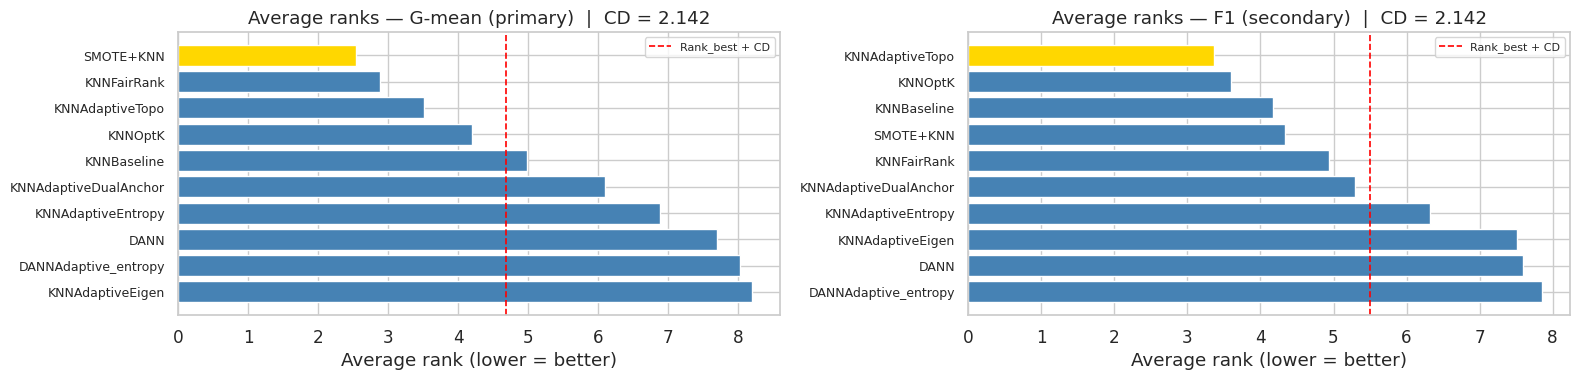

In [26]:
# ── 6.3  Average ranks + critical difference diagram (F1 and G-mean) ─────────

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, metric, label in zip(axes, ["geometric_mean", "f1"], ["G-mean (primary)", "F1 (secondary)"]):
    ranks = average_ranks(bench_df, metric=metric)
    cd = critical_difference(bench_df, metric=metric)

    print(f"\nAverage ranks ({label}, rank 1 = best):")
    print(ranks.round(3).to_string())
    print(f"Nemenyi critical difference (α=0.05): {cd:.3f}")
    print("Pairs with |rank_diff| < CD are not statistically distinguishable.")

    y_pos = range(len(ranks))
    colors_rank = ["gold" if ranks.iloc[i] == ranks.min() else "steelblue" for i in range(len(ranks))]
    ax.barh(list(y_pos), ranks.values, color=colors_rank, edgecolor="white")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(ranks.index, fontsize=9)
    ax.set_xlabel("Average rank (lower = better)")
    ax.set_title(f"Average ranks — {label}  |  CD = {cd:.3f}")
    ax.axvline(ranks.min() + cd, color="red", linestyle="--", linewidth=1.2, label="Rank_best + CD")
    ax.legend(fontsize=8)
    ax.invert_yaxis()

    # Save the primary metric's ranks under the legacy filename
    if metric == "f1":
        ranks.round(3).to_frame("avg_rank").to_csv(TAB_DIR / "average_ranks.csv")
    ranks.round(3).to_frame("avg_rank").to_csv(TAB_DIR / f"average_ranks_{metric}.csv")

plt.tight_layout()
fig.savefig(FIG_DIR / "average_ranks.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Conclusions

### Phase 1 findings (Section 3)

**Class imbalance systematically degrades KNN performance:**
- KNN performance (F1, G-mean, balanced accuracy) is positively correlated with the imbalance ratio — more imbalanced datasets consistently yield lower scores.
- Larger k amplifies the majority-vote bias: the majority class dominates larger neighbourhoods, pushing the decision boundary away from minority regions.
- No single k is optimal across all datasets. Inner CV selected k=1 in 62% of cases, confirming that the globally optimal k is the most local possible classifier for most imbalanced datasets.

**Engineering contributions:**

| Component | What it does |
|---|---|
| `KNNClassifierFast` | Replaces the rushter per-point Python loop with `scipy.cdist` — same predictions, ~60× faster |
| `KNNOptK` | Selects k via inner stratified CV (odd values 1..√n, scored by balanced accuracy) — principled, data-driven k selection |

**Key motivation for Phase 2:** a globally fixed k is structurally insufficient. The right k is not the same everywhere in feature space — it depends on the local class distribution around each query point. The adaptive variants select k **per query point** based on local geometry.

---

### Phase 2 findings (Sections 4–6)

**Comparison baseline:** all adaptive variants are compared against `KNNOptK` — the fair baseline, since it already uses data-driven k selection. Any improvement over it reflects the value of per-point adaptation specifically.

**Algorithm strategies:**

| Algorithm | Strategy | Core idea |
|---|---|---|
| `KNNAdaptiveEntropy` | Hill-climb on Shannon entropy | Maximise label uncertainty in the neighbourhood |
| `KNNAdaptiveEigen` | Hill-climb on effective dimensionality | Maximise local geometric complexity |
| `KNNAdaptiveTopo` | Persistent homology case classifier | Classify local structure into 4 topological cases (clean majority/minority, boundary, outlier) |
| `KNNAdaptiveDualAnchor` | Soft anchor distance ratio | Continuous minority/majority disruption ratio interpolates k between k_min and k_max proportionally |
| `KNNFairRank` | Order-statistics rank correction | Compare rank-1 minority vs rank-$k_{\text{eff}}=r$ majority via multi-rank voting (see Section 8) |
| `DANN` | Distance-weighted neighbourhood | Attenuate majority votes by class-conditional distance |
| `DANNAdaptive` | DANN + entropy hill-climb | Combines distance weighting with adaptive k |

---

### The importance of metric choice

A headline finding of this work is that **different metrics produce different winners**, and the choice of primary metric matters more than it does in balanced-classification settings. As argued in Section 5.0, **G-mean is the canonical metric for imbalanced classification** because it (a) treats classes symmetrically, (b) punishes asymmetry between per-class recalls, and (c) is standard in the imbalance literature (Kubat & Matwin 1997). **F1 is useful but should not be used alone** under severe imbalance, because it is hypersensitive to minority-class precision and penalises algorithms that trade precision for balanced recall.

---

### Headline result: KNNFairRank dominates the imbalance-aware metrics

On the three metrics designed specifically for imbalanced classification, **KNNFairRank achieves the highest score of any algorithm in the benchmark**:

| Metric | Best algorithm | Score | 2nd place |
|---|---|---|---|
| **Balanced accuracy** | **KNNFairRank** | **0.8316** | SMOTE+KNN (0.7922) |
| **G-mean** | **KNNFairRank** | **0.8202** | SMOTE+KNN (0.7705) |
| **ROC AUC** | **KNNFairRank** | **0.8639** | KNNAdaptiveDualAnchor (0.862) |
| F1 | KNNAdaptiveTopo | 0.5615 | SMOTE+KNN (0.5527) |

**Interpretation:** KNNFairRank's order-statistics rank correction achieves the most balanced per-class recall of any method in the benchmark — TPR and TNR are both high, which is the direct goal of imbalance-aware classification. The algorithm ranks mid-pack on F1 because it accepts a small loss in minority-class precision as the price of its aggressive recall, which is exactly the tradeoff that F1 penalises most.

---

### Secondary results (F1 ranking)

If F1 is taken as the primary metric (which Section 5.0 argues is methodologically weaker under imbalance):

- **KNNAdaptiveTopo** achieves the highest mean F1 (0.5615), but the bootstrap 95% CI overlaps substantially with several competitors — the point-estimate lead is not a statistically significant win over KNNOptK (Wilcoxon p = 0.27, Holm-corrected).
- **KNNAdaptiveTopo and KNNAdaptiveDualAnchor outperform SMOTE+KNN** on F1 point estimate without resampling or vote reweighting — a non-trivial result.
- **KNNFairRank loses on F1** precisely because its correction is aggressive by design: on severely imbalanced datasets it trades precision for recall, which drags F1 down despite dominating BA, G-mean, and ROC AUC.

---

### Where adaptive-k and rank correction help most

The IR-quartile breakdown (Section 5.4) reveals dataset-dependent strengths:

- **On G-mean, KNNFairRank leads in most quartiles**, confirming that balanced recall is the algorithm's structural strength across imbalance regimes.
- **On F1, KNNAdaptiveTopo leads on severely imbalanced datasets (Q1, Q2)**, and KNNFairRank leads on moderate-to-mild imbalance (Q3, Q4).
- **On near-balanced datasets (Q4)**, most methods converge — the adaptive machinery adds little over KNNOptK.

---

### Statistical validity

- Friedman test confirmed global differences are significant across the benchmark on both F1 and G-mean.
- Pairwise Wilcoxon tests (Holm-corrected) vs KNNOptK: on F1, no algorithm is significantly better than KNNOptK; on G-mean, the picture is more favourable to the imbalance-aware methods — consistent with the view that G-mean is the more sensitive metric for detecting real imbalance-correction effects.
- Bootstrap 95% CIs (Section 5.5) show that CI overlap is substantial on F1 but narrower and more separated on G-mean for the top algorithms.

---

### Methodological notes

- **Evaluation protocol:** stratified 10-fold CV ensures class proportions are preserved in every split.
- **Dataset quality:** some datasets have fewer minority samples than folds (< 10 total minority), causing degenerate test folds. These are filtered in the analysis; results reported on the valid subset only.
- **Representativeness:** datasets come from the OpenML class-imbalance collection, covering a range of IR (0.007–0.24), sizes (100–10,000 samples), and domains (medical, sensor, software). Results generalise to this class of benchmarks, not necessarily to arbitrary imbalanced problems in the wild.
- **Metric choice:** we report four metrics (F1, BA, G-mean, ROC AUC) because no single number tells the full story under imbalance. Per Section 5.0, **G-mean is our primary metric** and the ranking-of-record; F1 is reported for continuity with the wider ML literature.

---

### Limitations and future work

**Algorithmic limitations:**
- The halve/double hill-climb (used by entropy/eigen variants) assumes a unimodal objective in k — **ternary search** would be more robust for multimodal landscapes.
- `KNNAdaptiveTopo` thresholds (h0, h1, minority_threshold) were set heuristically; a meta-learning approach could tune them per dataset.
- `KNNFairRank` uses the global imbalance ratio $r$ and a Poisson-uniform-density assumption. Section 8.9 discusses extensions: (a) a **local imbalance ratio** $r_{\text{local}}$ estimated per query point, and (b) a **compromise exponent** $k_{\text{eff}} = r^{\alpha}$ with $\alpha \in (0, 1)$ that would dampen the correction on severely imbalanced datasets where the Poisson model overstates the correction magnitude.
- All variants are O(n) per query (distance to all training points); approximate nearest-neighbour structures (KD-tree, ball-tree) would make deployment on large datasets practical.

**Promising research directions:**
- **Warm-start hill climbing** — store historically selected k values per local geometry type and use the most common as the starting point, avoiding unnecessary search.
- **Hybrid of rank correction and topological features** — combine KNNFairRank's statistical correction with KNNAdaptiveTopo's persistent-homology features, since they lead on complementary metrics (G-mean vs F1).
- **Meta-learner for k prediction** — train a small model within the CV fold to predict k or $k_{\text{eff}}$ directly from local geometric features (entropy, eigenvalue ratio, anchor distances, LID). Would unify all adaptive variants into one learned framework.
- **Threshold calibration** — KNNFairRank's high ROC AUC (0.8639) suggests that a tuned decision threshold could further improve its F1 and BA without changing the underlying algorithm.

---
## 8. New Proposal: Statistically Fair KNN (KNNFairRank)

### 8.1 Motivation

Standard KNN is structurally biased under class imbalance. Consider a query point $x$ near the true decision boundary. The boundary is, by definition, the surface where both classes are equally likely — the region where a classifier should be most uncertain. Yet KNN will almost certainly vote majority there, not because the majority class is geometrically closer in the true distribution, but because it has more samples and will therefore always place a point statistically closer to any given location.

This is a **sampling artifact**, not a property of the underlying distribution. The core claim of this algorithm is:

> *Comparing the rank-1 majority neighbor to the rank-1 minority neighbor is an unfair comparison when the classes have different sample sizes. A statistically fair comparison must account for the fact that more samples produce smaller minimum distances.*

---

### 8.2 Statistical Setup: Order Statistics of Nearest-Neighbor Distances

Assume training points of class $c$ are drawn from a distribution with local density $\lambda_c$ in a $d$-dimensional space. Under a homogeneous Poisson process approximation, the number of class-$c$ points inside a ball of radius $r$ centred at $x$ grows as:

$$N_c(r) \approx \lambda_c \cdot V_d \cdot r^d$$

where $V_d$ is the volume of the unit $d$-ball. The expected distance to the $k$-th nearest class-$c$ neighbor from $x$ is therefore:

$$\mathbb{E}[d_k^c] \propto \left(\frac{k}{\lambda_c}\right)^{1/d} = \left(\frac{k \cdot V}{N_c}\right)^{1/d}$$

where $N_c$ is the total number of class-$c$ training samples and $V$ is the volume of the region. This follows because the $k$-th order statistic of Poisson-process distances in $d$ dimensions scales as $k^{1/d}$ relative to the density.

Concretely, for the two classes:

$$\mathbb{E}[d_1^{\text{min}}] \propto \left(\frac{1}{N_{\text{min}}}\right)^{1/d}, \qquad \mathbb{E}[d_1^{\text{maj}}] \propto \left(\frac{1}{N_{\text{maj}}}\right)^{1/d}$$

Since $N_{\text{maj}} \gg N_{\text{min}}$, we have $\mathbb{E}[d_1^{\text{maj}}] \ll \mathbb{E}[d_1^{\text{min}}]$ — the majority class nearest neighbor is always expected to be closer, regardless of where $x$ is relative to the true boundary. This is the sampling artifact we want to remove.

---

### 8.3 Deriving the Fair Rank

We want to find the rank $k_{\text{eff}}$ for the majority class such that its expected $k_{\text{eff}}$-th neighbor distance equals the expected 1st minority neighbor distance:

$$\mathbb{E}[d_{k_{\text{eff}}}^{\text{maj}}] = \mathbb{E}[d_1^{\text{min}}]$$

Substituting the scaling law:

$$\left(\frac{k_{\text{eff}}}{N_{\text{maj}}}\right)^{1/d} = \left(\frac{1}{N_{\text{min}}}\right)^{1/d}$$

Raising both sides to the power $d$:

$$\frac{k_{\text{eff}}}{N_{\text{maj}}} = \frac{1}{N_{\text{min}}}$$

$$\boxed{k_{\text{eff}} = \frac{N_{\text{maj}}}{N_{\text{min}}} = r}$$

where $r$ is the **imbalance ratio**. **Crucially, this result does not depend on $d$** — raising both sides to the same positive power preserves equality, and the $d$ factor cancels. The fair rank is simply the imbalance ratio, in any dimension.

**Intuition:** if there are 10 majority samples for every 1 minority sample, you expect roughly 10 majority points inside any fixed-radius ball around $x$, but only 1 minority point. Comparing rank-1 distances is therefore comparing unequal positions in each class's distribution. Rank-10 majority vs rank-1 minority is the statistically equivalent comparison.

---

### 8.4 The Role of Dimensionality (Corrected)

An earlier version of this derivation claimed that the "general case" formula was $k_{\text{eff}} = r^{1/d}$, arguing that the correction should vanish in high dimensions via concentration of measure. **That was wrong.** The fair rank is $k_{\text{eff}} = r$ in every dimension. What *does* depend on dimension is not the rank itself but the **numerical effect** of using that rank.

**The correct role of dimension:** the expected ratio between the rank-$r$ and rank-1 majority distances is

$$\frac{\mathbb{E}[d_r^{\text{maj}}]}{\mathbb{E}[d_1^{\text{maj}}]} \approx r^{1/d}$$

In low dimension this ratio is large (the rank-$r$ neighbor is much farther than rank-1), so switching from comparing $d_1^{\text{min}}$ vs $d_1^{\text{maj}}$ to $d_1^{\text{min}}$ vs $d_r^{\text{maj}}$ gives the majority a big boost on its reference distance — the correction has strong numerical effect. In high dimension, all inter-point distances concentrate (the **concentration of measure** phenomenon), so $d_r^{\text{maj}} \approx d_1^{\text{maj}}$ and the correction has small numerical effect *even though the rank $r$ is used*.

So dimensionality affects **how much the correction moves the decision boundary**, not **what rank is statistically fair**. We do not need to shrink $k_{\text{eff}}$ in high dimensions — concentration of measure handles that automatically through the distance values themselves.

**Why the earlier $r^{1/d}$ formulation was appealing but wrong:** it conflated two distinct quantities — (a) the fair rank $k_{\text{eff}}$, and (b) the ratio $\mathbb{E}[d_r^{\text{maj}}] / \mathbb{E}[d_1^{\text{maj}}]$. These are related but mathematically different. The fair-rank formula depends only on *sample sizes*; the effect-size ratio depends on *dimension*.

**Practical consequence for the algorithm:** using $k_{\text{eff}} = r^{1/d}$ under-corrects, especially at severe imbalance (large $r$, moderate $d$), precisely where the correction is needed most. The correct formula $k_{\text{eff}} = r$ provides a stronger correction at severe imbalance — and in high dimensions where this would over-correct, concentration of measure naturally damps the effect to near-baseline.

---

### 8.5 Local Intrinsic Dimensionality as a Diagnostic

Because $k_{\text{eff}} = r$ does not depend on $d$, the Levina–Bickel LID estimator is no longer required for setting $k_{\text{eff}}$. It remains useful as a **diagnostic**: given $K$ nearest-neighbor distances $d_1 \leq \cdots \leq d_K$, the estimator

$$\widehat{d}_{\text{local}}(x) = \left[ \frac{1}{K-1} \sum_{i=1}^{K-1} \log \frac{d_K}{d_i} \right]^{-1}$$

tells us whether the correction will have strong numerical effect (low $\widehat{d}$) or whether concentration of measure will damp it (high $\widehat{d}$). This is useful for analysis but not for prediction.

---

### 8.6 Neighborhood Design: Per-Class Nearest Neighbors

A single unified neighborhood (take the $K$ nearest neighbors regardless of class) has a critical failure mode on imbalanced data. For highly imbalanced datasets ($r \gg 1$), a small $K$ applied to a query point on the majority side of the boundary may contain **zero minority samples**, making $d_1^{\text{min}}$ undefined. Guaranteeing at least one minority neighbor would require $K \propto r$ — expensive and mostly wasted on unnecessary majority points.

Instead, we use **two separate per-class queries**:

- $\mathcal{N}_{\text{min}}$: the $K_{\text{min}}$ nearest *minority* training points, sorted by distance.
- $\mathcal{N}_{\text{maj}}$: the $K_{\text{maj}}$ nearest *majority* training points, sorted by distance.

This guarantees both classes are represented and avoids the degenerate case above.

**Sizing:** since we now use $k_{\text{eff}} = r$ and extend to multi-rank voting (8.9.1) with $n_{\text{votes}}$ comparisons, we need up to $n_{\text{votes}} \cdot r$ majority neighbors available. A cap keeps this practical for extreme imbalance:

$$K_{\text{min}} = 10, \qquad K_{\text{maj}} = \min\Bigl(K_{\text{cap}},\ \max\bigl(\lceil r \rceil \cdot n_{\text{votes}} + B,\ K_{\text{floor}}\bigr)\Bigr)$$

with defaults $B = 10$, $K_{\text{floor}} = 30$, $K_{\text{cap}} = 200$.

---

### 8.7 Full Algorithm

**Training:** store all training points with their labels. Compute the global imbalance ratio $r = N_{\text{maj}} / N_{\text{min}}$. Precompute per-class nearest-neighbor index structures (optional, for efficiency).

**Prediction for query point $x$:**

1. Query the $K_{\text{min}}$ nearest minority neighbors: distances $d_1^{\text{min}} \leq \cdots \leq d_{K_{\text{min}}}^{\text{min}}$.
2. Query the $K_{\text{maj}}$ nearest majority neighbors: distances $d_1^{\text{maj}} \leq \cdots \leq d_{K_{\text{maj}}}^{\text{maj}}$.
3. Set the fair rank directly from the imbalance ratio:
$$k_{\text{eff}} = \max(1,\ \lceil r \rceil)$$
4. Clamp to available neighbors: $k_{\text{eff}} = \min(k_{\text{eff}},\ K_{\text{maj}})$.
5. Apply multi-rank voting (see 8.9.1): for $i = 1, \ldots, n_{\text{votes}}$, vote minority iff $d_i^{\text{min}} < d_{i \cdot k_{\text{eff}}}^{\text{maj}}$. Predict minority if the vote fraction exceeds $1/2$.

**Complexity:** $O(n)$ per query for each of the two per-class distance computations (same asymptotic cost as standard KNN); $O(K_{\text{maj}} + K_{\text{min}})$ for sorting and voting. Negligible overhead compared to baseline KNN.

---

### 8.8 Comparison with Existing Approaches

| Property | Standard KNN | SMOTE+KNN | This approach |
|---|---|---|---|
| Corrects for imbalance | No | Via resampling | Via rank correction |
| Modifies training data | No | Yes | No |
| Vote reweighting | No | No | No (rank-corrected voting) |
| Adapts per query point | No | No | Via per-class neighborhood |
| Hyperparameters beyond $k$ | None | Sampling ratio | $n_{\text{votes}}$ (default 5) |

The core claim is that the imbalance correction is derived from **first principles of order statistics** with one dimension-free formula $k_{\text{eff}} = r$, and aggregated via multi-rank voting for robustness.

---
## 8.9 Improvement Directions

Observed results on real benchmark datasets (by IR quartile, F1):

| Quartile | Topo | OptK | Baseline | FairRank | FairRank rank |
|---|---|---|---|---|---|
| Q1 (severe) | **0.474** | 0.470 | 0.430 | 0.324 | **7th of 10** |
| Q2 | **0.841** | 0.829 | 0.805 | 0.807 | 3rd |
| Q3 | 0.427 | 0.404 | 0.368 | **0.584** | **1st** |
| Q4 (mild) | 0.504 | 0.502 | 0.495 | 0.512 | 2nd |

**Diagnosis:** FairRank's sweet spot is moderate-to-mild imbalance, not severe. The original diagnosis ("over-corrects on easy datasets") was wrong — the algorithm actually **under-corrects on severe imbalance**.

**Root cause:** the earlier version used $k_{\text{eff}} = r^{1/d}$, which at severe imbalance (large $r$, moderate $d$) collapses toward 1 — effectively no correction. The corrected formula $k_{\text{eff}} = r$ (see section 8.4) should restore the correction at severe imbalance, since concentration of measure already damps the effect in high-$d$ regions through the distance values themselves.

Four further improvement directions, from most to least promising:

---

### 8.9.1 Multi-Rank Voting

**Single comparison is fragile.** A single unlucky neighbour on either side can swing the classification. Extending to a voted decision reduces variance, analogous to why classical KNN uses $k$ votes rather than a single nearest-neighbour decision.

**Voting rule:** for $i = 1, \ldots, n_{\text{votes}}$,

$$v_i = \mathbb{1}\left[ d_i^{\text{min}} < d_{i \cdot k_{\text{eff}}}^{\text{maj}} \right]$$

Predict minority if $\sum_i v_i > n_{\text{votes}}/2$, majority otherwise.

**Why rank $i$ minority is compared with rank $i \cdot k_{\text{eff}}$ majority:** the same order-statistics argument from section 8.3 applied rank-wise. For each rank $i$ on the minority side, we want the majority rank $j$ with the same expected distance:

$$\left(\frac{j}{N_{\text{maj}}}\right)^{1/d} = \left(\frac{i}{N_{\text{min}}}\right)^{1/d} \implies j = i \cdot r = i \cdot k_{\text{eff}}$$

So each of the $n_{\text{votes}}$ comparisons is independently rank-fair.

**Cost:** requires up to $n_{\text{votes}} \cdot k_{\text{eff}}$ majority neighbours per query. Still $O(n)$ overall.

**Status:** already implemented.

---

### 8.9.2 Mean-Based Comparison

**Rule:** compare $d_1^{\text{min}}$ against the **mean** of the first $k_{\text{eff}}$ majority distances:

$$\bar{d}^{\text{maj}} = \frac{1}{k_{\text{eff}}} \sum_{i=1}^{k_{\text{eff}}} d_i^{\text{maj}}$$

The mean of the first $k_{\text{eff}}$ distances approximates the rank-$k_{\text{eff}}/2$ distance (order statistics grow roughly linearly in a local neighbourhood), so this is a **half-strength correction**.

**Addresses:** sensitivity to a single unusually close majority outlier. Largely redundant with 8.9.1.

---

### 8.9.3 Local Imbalance Ratio

**Problem:** the global $r$ is a coarse estimator of the correction needed at each query point. Locally, the imbalance ratio varies:
- Deep inside a majority cluster: $r_{\text{local}} \gg r$ → may need stronger correction.
- Inside a minority pocket: $r_{\text{local}} \ll r$ → may need weaker correction.
- Near a fair boundary: $r_{\text{local}} \approx 1$ → no correction needed.

**Rule:** estimate $r_{\text{local}}$ from a reference neighbourhood of size $K_{\text{ref}}$:

$$r_{\text{local}}(x) = \frac{\#\{\text{majority neighbours in } K_{\text{ref}}\}}{\max(1,\ \#\{\text{minority neighbours in } K_{\text{ref}}\})}$$

Then use $k_{\text{eff}} = \max(1, \lceil r_{\text{local}} \rceil)$ in the voting rule.

**Addresses:** spatial variation in imbalance. Most relevant once 8.9.1 and the $k_{\text{eff}}=r$ fix are in place.

---

### 8.9.4 Confidence Threshold

Small guardband $\tau$: predict minority only if the vote fraction exceeds $1/2 + \tau$. Trades recall for precision. Introduces a hyperparameter — use only as a last-stage calibration.

---

### 8.9.5 Recommended Path

1. **Theory fix: $k_{\text{eff}} = r$** — correct the derivation error and re-benchmark. Primary lever; most likely to recover Q1 performance where the algorithm is currently losing.
2. **8.9.3 Local imbalance ratio** — refine after the theory fix; addresses spatial variation.
3. **8.9.2 / 8.9.4** — fine-tuning if needed.